# Real-Time Human Activity Recognition from Smartphone Sensors
## Deep Transformer Notebook v2 - UCI HAR + optional Phyphox

מחברת מוכנה להרצה לפרויקט HAR מבוסס Transformer.

מה יש כאן:

1. טעינת UCI HAR, כולל תמיכה בהעלאת zip, תיקייה מלאה או קבצים שטוחים.
2. Baseline קלאסי על 561 engineered features.
3. Baseline signal-processing עם handcrafted + FFT features.
4. Subject-wise validation כדי לבדוק generalization לאנשים שלא הופיעו באימון.
5. Transformer Encoder על raw sensor windows בגודל `128 x 9`.
6. Ablation study לפי validation בלבד: positional encoding, pooling, depth, heads, patching.
7. Patch Transformer.
8. CNN-Transformer Hybrid לעיבוד סיגנלים: local convolution + global attention.
9. Sensor ablation: accelerometer only, gyroscope only, total acceleration only, body acceleration only.
10. Attention visualization ו-attention heatmaps.
11. Error analysis, per-subject analysis, calibration ו-confidence analysis.
12. Single-window inference.
13. Phyphox adapter עם resampling ל-50Hz ופירוק acceleration ל-body/gravity בעזרת Butterworth low-pass filter.

הרעיון המרכזי: לא רק להריץ Transformer, אלא להראות למה בחרנו את הארכיטקטורה, מה משפיע עליה, איפה היא מתבלבלת, ואיך אפשר לחבר אותה לדאטה חי מסמארטפון.


In [2]:
# =========================
# 0. Setup
# =========================
import os
import io
import math
import zipfile
import random
import urllib.request
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

try:
    from scipy.signal import butter, filtfilt
    SCIPY_AVAILABLE = True
except Exception as e:
    SCIPY_AVAILABLE = False
    print("SciPy signal import failed. Phyphox Butterworth preprocessing will not work until scipy is installed.", e)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


## 1. Configuration

`FAST_DEMO=True` מריץ ניסויים קצרים יחסית כדי שהמחברת תעבוד מהר ב-Colab.

להרצה רצינית יותר לפני הגשה, אפשר לשנות ל-`False` או להגדיל epochs.

In [3]:
# =========================
# 1. Configuration
# =========================
FAST_DEMO = True

# Training settings
BATCH_SIZE = 128
MAIN_EPOCHS = 8 if FAST_DEMO else 20
ABLATION_EPOCHS = 4 if FAST_DEMO else 10
PATCH_EPOCHS = 8 if FAST_DEMO else 20
CNN_TRANSFORMER_EPOCHS = 8 if FAST_DEMO else 20
SENSOR_ABLATION_EPOCHS = 3 if FAST_DEMO else 8
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

# Validation strategy
VALIDATION_SUBJECT_FRACTION = 0.20
MIN_VALIDATION_SUBJECTS = 3

# Transformer settings
DEFAULT_D_MODEL = 64
DEFAULT_HEADS = 4
DEFAULT_LAYERS = 2
DEFAULT_DROPOUT = 0.15
DEFAULT_DIM_FF = 128

# UCI HAR sensor names and channel order
SIGNAL_NAMES = [
    "total_acc_x", "total_acc_y", "total_acc_z",
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
]

CHANNEL_GROUPS = {
    "all_sensors": list(range(9)),
    "acceleration_only_total_plus_body": [0, 1, 2, 3, 4, 5],
    "gyroscope_only": [6, 7, 8],
    "total_acc_only": [0, 1, 2],
    "body_acc_only": [3, 4, 5],
}

CLASS_NAMES = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]

print("FAST_DEMO:", FAST_DEMO)
print("MAIN_EPOCHS:", MAIN_EPOCHS)
print("ABLATION_EPOCHS:", ABLATION_EPOCHS)
print("PATCH_EPOCHS:", PATCH_EPOCHS)
print("CNN_TRANSFORMER_EPOCHS:", CNN_TRANSFORMER_EPOCHS)
print("SENSOR_ABLATION_EPOCHS:", SENSOR_ABLATION_EPOCHS)


FAST_DEMO: True
MAIN_EPOCHS: 8
ABLATION_EPOCHS: 4
PATCH_EPOCHS: 8
CNN_TRANSFORMER_EPOCHS: 8
SENSOR_ABLATION_EPOCHS: 3


## 2. Data acquisition and loading

הדאטה המקורי בנוי כך שכל חלון הוא 2.56 שניות, נדגם ב-50Hz, כלומר 128 דגימות לכל חלון.

ל-Transformer נשתמש ב-raw inertial signals בגודל:

```text
N samples x 128 timesteps x 9 sensor channels
```

ל-baselines נשתמש גם ב-561 engineered features המוכנים של UCI.

In [4]:
# =========================
# 2. Data acquisition
# =========================
DATA_DIR = Path("./data")
UCI_DIR = DATA_DIR / "UCI HAR Dataset"
LOCAL_FLAT_DIRS = [Path("."), Path("/mnt/data"), DATA_DIR]

UCI_URLS = [
    "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip",
    "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip",
]


def exists_txt_or_stem(folder: Path, stem: str) -> bool:
    """Support both file.txt and file names without .txt, just in case."""
    return (folder / f"{stem}.txt").exists() or (folder / stem).exists()


def resolve_txt_or_stem(folder: Path, stem: str) -> Path:
    for candidate in [folder / f"{stem}.txt", folder / stem]:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {stem}.txt or {stem} under {folder}")


def has_full_uci_structure(base: Path) -> bool:
    required = [
        base / "activity_labels.txt",
        base / "features.txt",
        base / "train" / "X_train.txt",
        base / "train" / "y_train.txt",
        base / "test" / "X_test.txt",
        base / "test" / "y_test.txt",
        base / "train" / "Inertial Signals" / "body_acc_x_train.txt",
        base / "test" / "Inertial Signals" / "body_acc_x_test.txt",
    ]
    return all(p.exists() for p in required)


def has_flat_raw_dataset(folder: Path) -> bool:
    """Support the common case where all files were uploaded into one flat folder."""
    if not folder.exists():
        return False
    required_stems = [
        "X_train", "X_test",
        "y_train", "y_test",
        "subject_train", "subject_test",
    ]
    for split in ["train", "test"]:
        required_stems += [f"{sig}_{split}" for sig in SIGNAL_NAMES]
    return all(exists_txt_or_stem(folder, stem) for stem in required_stems)


def find_uploaded_zip() -> Optional[Path]:
    for folder in LOCAL_FLAT_DIRS:
        if not folder.exists():
            continue
        for p in folder.glob("*.zip"):
            if "HAR" in p.name.upper() or "activity" in p.name.lower() or "smartphone" in p.name.lower():
                return p
    return None


def extract_zip(zip_path: Path, target_dir: Path) -> None:
    target_dir.mkdir(parents=True, exist_ok=True)
    print(f"Extracting {zip_path} ...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(target_dir)


def download_uci_har() -> None:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    zip_path = DATA_DIR / "UCI_HAR_Dataset.zip"
    last_error = None
    for url in UCI_URLS:
        try:
            print("Downloading UCI HAR from:", url)
            urllib.request.urlretrieve(url, zip_path)
            extract_zip(zip_path, DATA_DIR)
            if has_full_uci_structure(UCI_DIR):
                print("UCI HAR downloaded successfully.")
                return
        except Exception as e:
            last_error = e
            print("Download failed:", e)
    raise RuntimeError(
        "Could not download UCI HAR automatically. "
        "Upload the full UCI HAR Dataset zip to Colab or place the extracted folder under ./data. "
        f"Last error: {last_error}"
    )


def ensure_dataset() -> Path:
    # 1. Already extracted full structure
    if has_full_uci_structure(UCI_DIR):
        print("Found full UCI HAR structure at", UCI_DIR)
        return UCI_DIR

    # 2. Maybe user uploaded/extracted the full UCI structure in current directory, /mnt/data, or as UCI HAR Dataset folder
    for candidate in [Path("."), Path("/mnt/data"), Path("UCI HAR Dataset"), Path("/mnt/data/UCI HAR Dataset")]:
        if has_full_uci_structure(candidate):
            print("Found full UCI HAR structure at", candidate)
            return candidate

    # 3. Maybe user uploaded all files into one flat folder
    for folder in LOCAL_FLAT_DIRS:
        if has_flat_raw_dataset(folder):
            print("Found complete flat UCI HAR upload at", folder)
            return folder

    # 4. Maybe user uploaded a zip
    zip_path = find_uploaded_zip()
    if zip_path is not None:
        extract_zip(zip_path, DATA_DIR)
        if has_full_uci_structure(UCI_DIR):
            return UCI_DIR
        for folder in [DATA_DIR, UCI_DIR]:
            if has_flat_raw_dataset(folder):
                return folder

    # 5. Download in Colab
    download_uci_har()
    return UCI_DIR

uci_base = ensure_dataset()
print("Using dataset base:", uci_base)


Extracting data/UCI_HAR_Dataset.zip ...
UCI HAR downloaded successfully.
Using dataset base: data/UCI HAR Dataset


In [5]:
# =========================
# 3. Load UCI HAR
# =========================

def load_txt_matrix(path: Path) -> np.ndarray:
    return np.loadtxt(path)


def find_file(split: str, name: str, uci_base: Path) -> Path:
    """Find file in full UCI structure first, then in flat uploaded folders."""
    if name in ["X", "y", "subject"]:
        structured_folder = uci_base / split
        structured_stem = f"{name}_{split}"
    else:
        structured_folder = uci_base / split / "Inertial Signals"
        structured_stem = f"{name}_{split}"

    for candidate in [structured_folder / f"{structured_stem}.txt", structured_folder / structured_stem]:
        if candidate.exists():
            return candidate

    # fallback for flat uploads such as /mnt/data/body_acc_x_train.txt
    flat_stem = f"{name}_{split}"
    for folder in LOCAL_FLAT_DIRS:
        if exists_txt_or_stem(folder, flat_stem):
            return resolve_txt_or_stem(folder, flat_stem)
    raise FileNotFoundError(f"Missing file for {split}/{name}: expected {structured_folder / (structured_stem + '.txt')} or flat {flat_stem}.txt")


def load_engineered_features(split: str, uci_base: Path) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    X = load_txt_matrix(find_file(split, "X", uci_base))
    y = load_txt_matrix(find_file(split, "y", uci_base)).astype(int) - 1
    subject = load_txt_matrix(find_file(split, "subject", uci_base)).astype(int)
    return X, y, subject


def load_raw_signals(split: str, uci_base: Path, signal_names: List[str]) -> np.ndarray:
    signals = []
    missing = []
    for sig in signal_names:
        try:
            path = find_file(split, sig, uci_base)
            arr = load_txt_matrix(path)  # shape: samples x 128
            signals.append(arr)
        except FileNotFoundError as e:
            missing.append(str(e))
    if missing:
        raise FileNotFoundError("Missing raw signal files:\n" + "\n".join(missing[:5]))
    # stack to: samples x timesteps x channels
    return np.stack(signals, axis=-1).astype(np.float32)

X_train_feat, y_train, subject_train = load_engineered_features("train", uci_base)
X_test_feat, y_test, subject_test = load_engineered_features("test", uci_base)

X_train_raw = load_raw_signals("train", uci_base, SIGNAL_NAMES)
X_test_raw = load_raw_signals("test", uci_base, SIGNAL_NAMES)

print("Engineered train:", X_train_feat.shape, y_train.shape)
print("Engineered test: ", X_test_feat.shape, y_test.shape)
print("Raw train:       ", X_train_raw.shape)
print("Raw test:        ", X_test_raw.shape)
print("Train labels:", np.bincount(y_train))
print("Test labels: ", np.bincount(y_test))
print("Train subjects:", sorted(np.unique(subject_train).tolist()))
print("Test subjects:", sorted(np.unique(subject_test).tolist()))


Engineered train: (7352, 561) (7352,)
Engineered test:  (2947, 561) (2947,)
Raw train:        (7352, 128, 9)
Raw test:         (2947, 128, 9)
Train labels: [1226 1073  986 1286 1374 1407]
Test labels:  [496 471 420 491 532 537]
Train subjects: [1, 3, 5, 6, 7, 8, 11, 14, 15, 16, 17, 19, 21, 22, 23, 25, 26, 27, 28, 29, 30]
Test subjects: [2, 4, 9, 10, 12, 13, 18, 20, 24]


## 3. Exploratory checks

נבדוק דוגמה אחת של raw signal. זה עוזר להסביר בהצגה מה המודל מקבל בפועל.

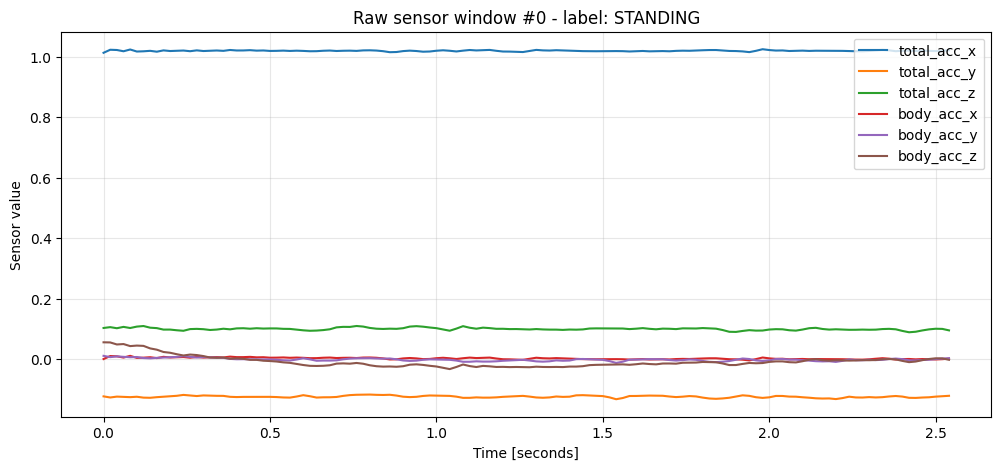

In [6]:
# =========================
# 4. Visualize one raw window
# =========================
def plot_raw_window(X_raw: np.ndarray, y: np.ndarray, idx: int = 0, channels: Optional[List[int]] = None):
    if channels is None:
        channels = list(range(min(6, X_raw.shape[-1])))
    t = np.arange(X_raw.shape[1]) / 50.0  # seconds
    plt.figure(figsize=(12, 5))
    for c in channels:
        plt.plot(t, X_raw[idx, :, c], label=SIGNAL_NAMES[c])
    plt.title(f"Raw sensor window #{idx} - label: {CLASS_NAMES[y[idx]]}")
    plt.xlabel("Time [seconds]")
    plt.ylabel("Sensor value")
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_raw_window(X_train_raw, y_train, idx=0)

## 4. Baseline 1 - Logistic Regression on 561 engineered features

זה baseline חשוב כי UCI כבר מספק 561 פיצ׳רים סטטיסטיים ותדריים.

המטרה היא להשוות: האם Transformer על raw sequence מצליח להתקרב/לעבור feature engineering קלאסי?

In [7]:
# =========================
# 5. Baseline: Logistic Regression on engineered features
# =========================
scaler_feat = StandardScaler()
X_train_feat_scaled = scaler_feat.fit_transform(X_train_feat)
X_test_feat_scaled = scaler_feat.transform(X_test_feat)

logreg = LogisticRegression(max_iter=1000, n_jobs=-1, C=2.0)
logreg.fit(X_train_feat_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_feat_scaled)

baseline_results = []
baseline_results.append({
    "model": "Logistic Regression - 561 engineered features",
    "accuracy": accuracy_score(y_test, y_pred_logreg),
    "macro_f1": f1_score(y_test, y_pred_logreg, average="macro"),
})

print("Logistic Regression baseline")
print("Accuracy:", baseline_results[-1]["accuracy"])
print("Macro F1:", baseline_results[-1]["macro_f1"])
print(classification_report(y_test, y_pred_logreg, target_names=CLASS_NAMES))

Logistic Regression baseline
Accuracy: 0.9586019681031558
Macro F1: 0.9582742862415957
                    precision    recall  f1-score   support

           WALKING       0.95      0.99      0.97       496
  WALKING_UPSTAIRS       0.96      0.96      0.96       471
WALKING_DOWNSTAIRS       0.99      0.94      0.96       420
           SITTING       0.97      0.88      0.92       491
          STANDING       0.90      0.97      0.94       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.96      2947
         macro avg       0.96      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947



## 5. Baseline 2 - Handcrafted signal features + FFT

כאן אנחנו יוצרים בעצמנו feature engineering מתוך raw signals:

- mean/std/min/max
- energy
- FFT dominant frequency
- spectral entropy
- spectral energy
- mean frequency

זה מחבר בין signal processing לבין ה-Transformer.

In [8]:
# =========================
# 6. Handcrafted signal features with FFT
# =========================

def spectral_entropy(power: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    p = power / (np.sum(power, axis=1, keepdims=True) + eps)
    return -np.sum(p * np.log(p + eps), axis=1)


def make_signal_features(X_raw: np.ndarray, sampling_rate: float = 50.0) -> pd.DataFrame:
    # X_raw: samples x time x channels
    n, t, c = X_raw.shape
    feats = {}
    freqs = np.fft.rfftfreq(t, d=1.0 / sampling_rate)

    for ch in range(c):
        sig = X_raw[:, :, ch]
        name = SIGNAL_NAMES[ch]

        feats[f"{name}_mean"] = sig.mean(axis=1)
        feats[f"{name}_std"] = sig.std(axis=1)
        feats[f"{name}_min"] = sig.min(axis=1)
        feats[f"{name}_max"] = sig.max(axis=1)
        feats[f"{name}_energy"] = np.mean(sig ** 2, axis=1)
        feats[f"{name}_iqr"] = np.percentile(sig, 75, axis=1) - np.percentile(sig, 25, axis=1)

        fft_vals = np.fft.rfft(sig, axis=1)
        power = np.abs(fft_vals) ** 2
        # Ignore DC component when looking for dominant movement frequency
        power_no_dc = power[:, 1:]
        freq_no_dc = freqs[1:]

        dominant_idx = np.argmax(power_no_dc, axis=1)
        feats[f"{name}_fft_dominant_freq"] = freq_no_dc[dominant_idx]
        feats[f"{name}_fft_total_power"] = power.sum(axis=1)
        feats[f"{name}_fft_entropy"] = spectral_entropy(power)
        feats[f"{name}_fft_mean_freq"] = (power * freqs[None, :]).sum(axis=1) / (power.sum(axis=1) + 1e-12)

    return pd.DataFrame(feats)

X_train_hand = make_signal_features(X_train_raw)
X_test_hand = make_signal_features(X_test_raw)
print("Handcrafted train features:", X_train_hand.shape)
X_train_hand.head()

Handcrafted train features: (7352, 90)


,total_acc_x_mean,total_acc_x_std,total_acc_x_min,total_acc_x_max,total_acc_x_energy,total_acc_x_iqr,total_acc_x_fft_dominant_freq,total_acc_x_fft_total_power,total_acc_x_fft_entropy,total_acc_x_fft_mean_freq,...,body_gyro_z_mean,body_gyro_z_std,body_gyro_z_min,body_gyro_z_max,body_gyro_z_energy,body_gyro_z_iqr,body_gyro_z_fft_dominant_freq,body_gyro_z_fft_total_power,body_gyro_z_fft_entropy,body_gyro_z_fft_mean_freq
0,1.019305,0.001791,1.012817,1.024606,1.038985,0.002154,3.125000,17022.699219,0.000028,0.000015,...,0.009468,0.005943,-0.006891,0.022859,0.000125,0.008300,0.390625,1.758145,0.932545,0.729464
1,1.019448,0.001932,1.012893,1.024606,1.039278,0.002227,5.078125,17027.496094,0.000031,0.000012,...,0.006308,0.007431,-0.009759,0.025133,0.000095,0.010422,0.390625,1.104177,1.617602,1.071706
2,1.019927,0.002904,1.009013,1.027664,1.040259,0.003096,5.859375,17043.527344,0.000068,0.000025,...,0.004335,0.008753,-0.009759,0.028609,0.000095,0.013243,0.390625,0.935554,2.251963,1.747090
3,1.020349,0.002574,1.009013,1.027664,1.041119,0.002786,7.421875,17057.636719,0.000053,0.000020,...,-0.000352,0.008186,-0.013223,0.028609,0.000067,0.006907,1.562500,0.551072,2.484986,2.343929
4,1.020255,0.001949,1.013645,1.026194,1.040925,0.002506,7.031250,17054.478516,0.000032,0.000011,...,-0.003957,0.008260,-0.021141,0.019890,0.000084,0.009755,0.390625,0.815475,2.154012,1.472515


In [9]:
rf = RandomForestClassifier(
    n_estimators=300 if FAST_DEMO else 600,
    max_depth=None,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1,
)
rf.fit(X_train_hand, y_train)
y_pred_rf = rf.predict(X_test_hand)

baseline_results.append({
    "model": "Random Forest - handcrafted time + FFT features",
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "macro_f1": f1_score(y_test, y_pred_rf, average="macro"),
})

print("Random Forest handcrafted signal baseline")
print("Accuracy:", baseline_results[-1]["accuracy"])
print("Macro F1:", baseline_results[-1]["macro_f1"])
print(classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES))

Random Forest handcrafted signal baseline
Accuracy: 0.9104173736002714
Macro F1: 0.9073922452930089
                    precision    recall  f1-score   support

           WALKING       0.91      0.97      0.94       496
  WALKING_UPSTAIRS       0.88      0.93      0.90       471
WALKING_DOWNSTAIRS       0.92      0.80      0.86       420
           SITTING       0.88      0.85      0.87       491
          STANDING       0.87      0.89      0.88       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.91      2947
         macro avg       0.91      0.91      0.91      2947
      weighted avg       0.91      0.91      0.91      2947



## 6. Prepare raw sequence data for Transformer

כאן אנחנו מנרמלים את ערוצי ה-raw signal לפי הסטטיסטיקות של train בלבד.

שינוי מתודולוגי חשוב בגרסה הזו: ה-validation הוא **subject-wise**. כלומר, אנשים מסוימים נשמרים ל-validation, ולא רק חלונות אקראיים. זה בודק טוב יותר האם המודל מכליל לאדם חדש, ולא רק לחלון חדש של אותו אדם.


In [10]:
# =========================
# 7. Torch Dataset + subject-wise validation
# =========================
# Standardize raw channels using train statistics only
raw_mean = X_train_raw.reshape(-1, X_train_raw.shape[-1]).mean(axis=0)
raw_std = X_train_raw.reshape(-1, X_train_raw.shape[-1]).std(axis=0) + 1e-8

X_train_raw_scaled = (X_train_raw - raw_mean) / raw_std
X_test_raw_scaled = (X_test_raw - raw_mean) / raw_std

class HARRawDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray, subjects: Optional[np.ndarray] = None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.subjects = None if subjects is None else torch.tensor(subjects, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        if self.subjects is None:
            return self.X[idx], self.y[idx]
        return self.X[idx], self.y[idx], self.subjects[idx]

train_full_ds = HARRawDataset(X_train_raw_scaled, y_train, subject_train)
test_ds_with_subjects = HARRawDataset(X_test_raw_scaled, y_test, subject_test)
test_ds = HARRawDataset(X_test_raw_scaled, y_test)

# Subject-wise validation split from UCI train set.
# This avoids leakage where windows from the same person appear in both train and validation.
unique_subjects = np.array(sorted(np.unique(subject_train)))
rng = np.random.default_rng(SEED)
val_subject_count = max(MIN_VALIDATION_SUBJECTS, int(np.ceil(VALIDATION_SUBJECT_FRACTION * len(unique_subjects))))
val_subjects = np.sort(rng.choice(unique_subjects, size=val_subject_count, replace=False))
train_subjects = np.array([s for s in unique_subjects if s not in set(val_subjects)])

train_indices = np.where(np.isin(subject_train, train_subjects))[0]
val_indices = np.where(np.isin(subject_train, val_subjects))[0]

train_ds = Subset(train_full_ds, train_indices.tolist())
val_ds = Subset(train_full_ds, val_indices.tolist())

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_with_subjects = DataLoader(test_ds_with_subjects, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Subject-wise validation")
print("Train subjects:", train_subjects.tolist())
print("Validation subjects:", val_subjects.tolist())
print("Train windows:", len(train_ds))
print("Validation windows:", len(val_ds))
print("Test windows:", len(test_ds))
print("Train class distribution:", np.bincount(y_train[train_indices], minlength=len(CLASS_NAMES)))
print("Validation class distribution:", np.bincount(y_train[val_indices], minlength=len(CLASS_NAMES)))


Subject-wise validation
Train subjects: [1, 5, 6, 7, 8, 11, 14, 17, 19, 23, 25, 26, 27, 28, 29, 30]
Validation subjects: [3, 15, 16, 21, 22]
Train windows: 5588
Validation windows: 1764
Test windows: 2947
Train class distribution: [ 965  826  767  959 1030 1041]
Validation class distribution: [261 247 219 327 344 366]


## 7. Transformer implementation

המודל כולל:

- Linear projection מ-9 channels ל-`d_model`.
- positional encoding: none / sinusoidal / learnable.
- Transformer Encoder blocks עם Multi-Head Self-Attention.
- pooling: mean או CLS token.
- classification head ל-6 פעילויות.

בנוסף, המודל יכול להחזיר attention weights כדי לנתח מה הוא למד.

In [11]:
# =========================
# 8. Transformer implementation with attention extraction
# =========================
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))  # 1 x max_len x d_model

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, :x.size(1), :]


class LearnablePositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()
        self.pe = nn.Parameter(torch.zeros(1, max_len, d_model))
        nn.init.trunc_normal_(self.pe, std=0.02)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, :x.size(1), :]


class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model: int, nhead: int, dim_feedforward: int, dropout: float):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            dropout=dropout,
            batch_first=True,
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, return_attn: bool = False):
        attn_out, attn_weights = self.self_attn(
            x, x, x,
            need_weights=return_attn,
            average_attn_weights=False,
        )
        x = self.norm1(x + self.dropout(attn_out))
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))
        return x, attn_weights


class SensorTransformer(nn.Module):
    def __init__(
        self,
        input_channels: int = 9,
        seq_len: int = 128,
        num_classes: int = 6,
        d_model: int = 64,
        nhead: int = 4,
        num_layers: int = 2,
        dim_feedforward: int = 128,
        dropout: float = 0.15,
        pe_type: str = "sinusoidal",  # none / sinusoidal / learnable
        pooling: str = "mean",        # mean / cls
        patch_size: int = 1,
    ):
        super().__init__()
        assert pooling in ["mean", "cls"]
        assert pe_type in ["none", "sinusoidal", "learnable"]
        assert seq_len % patch_size == 0, "For simplicity, seq_len must be divisible by patch_size."

        self.input_channels = input_channels
        self.seq_len = seq_len
        self.num_classes = num_classes
        self.d_model = d_model
        self.nhead = nhead
        self.num_layers = num_layers
        self.pe_type = pe_type
        self.pooling = pooling
        self.patch_size = patch_size
        self.num_tokens = seq_len // patch_size

        token_input_dim = input_channels * patch_size
        self.input_proj = nn.Linear(token_input_dim, d_model)

        extra_cls = 1 if pooling == "cls" else 0
        max_len = self.num_tokens + extra_cls

        if pe_type == "sinusoidal":
            self.pos_encoder = SinusoidalPositionalEncoding(d_model, max_len=max_len)
        elif pe_type == "learnable":
            self.pos_encoder = LearnablePositionalEncoding(d_model, max_len=max_len)
        else:
            self.pos_encoder = nn.Identity()

        if pooling == "cls":
            self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
            nn.init.trunc_normal_(self.cls_token, std=0.02)
        else:
            self.cls_token = None

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(d_model, nhead, dim_feedforward, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, num_classes)
        )

    def patchify(self, x: torch.Tensor) -> torch.Tensor:
        # x: B x T x C
        if self.patch_size == 1:
            return x
        b, t, c = x.shape
        x = x.reshape(b, self.num_tokens, self.patch_size * c)
        return x

    def forward(self, x: torch.Tensor, return_attn: bool = False):
        # x: B x 128 x 9
        x = self.patchify(x)
        x = self.input_proj(x)

        if self.pooling == "cls":
            cls = self.cls_token.expand(x.size(0), -1, -1)
            x = torch.cat([cls, x], dim=1)

        x = self.pos_encoder(x)
        x = self.dropout(x)

        all_attn = []
        for block in self.blocks:
            x, attn = block(x, return_attn=return_attn)
            if return_attn:
                all_attn.append(attn.detach())

        if self.pooling == "cls":
            pooled = x[:, 0]
        else:
            pooled = x.mean(dim=1)

        logits = self.classifier(pooled)
        if return_attn:
            return logits, all_attn
        return logits


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model_test = SensorTransformer()
print(model_test)
print("Trainable parameters:", count_parameters(model_test))

SensorTransformer(
  (input_proj): Linear(in_features=9, out_features=64, bias=True)
  (pos_encoder): SinusoidalPositionalEncoding()
  (blocks): ModuleList(
    (0-1): 2 x TransformerEncoderBlock(
      (self_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.15, inplace=False)
        (3): Linear(in_features=128, out_features=64, bias=True)
      )
      (dropout): Dropout(p=0.15, inplace=False)
    )
  )
  (dropout): Dropout(p=0.15, inplace=False)
  (classifier): Sequential(
    (0): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=64, out_features=6, bias=True)
  )
)
Trainable parameters: 

## 8.1 CNN-Transformer Hybrid

Transformer טהור לומד קשרים גלובליים בין נקודות זמן, אבל בעיבוד סיגנלים יש גם דפוסים מקומיים חשובים: צעדים, תנודות קצרות ושינויי תאוצה. לכן נוסיף מודל היברידי:

```text
Raw signal -> 1D Convolution -> Transformer Encoder -> Classification head
```

ה-Convolution לומד patterns מקומיים, וה-Transformer לומד קשרים גלובליים לאורך החלון.


In [12]:
# =========================
# 8.1 CNN-Transformer Hybrid model
# =========================
class CNNTransformerClassifier(nn.Module):
    def __init__(
        self,
        input_channels: int = 9,
        seq_len: int = 128,
        num_classes: int = 6,
        d_model: int = 64,
        nhead: int = 4,
        num_layers: int = 2,
        dim_feedforward: int = 128,
        dropout: float = 0.15,
        pe_type: str = "sinusoidal",
        pooling: str = "cls",
        conv_kernel_size: int = 5,
    ):
        super().__init__()
        assert pooling in ["mean", "cls"]
        assert pe_type in ["none", "sinusoidal", "learnable"]
        self.input_channels = input_channels
        self.seq_len = seq_len
        self.num_classes = num_classes
        self.d_model = d_model
        self.nhead = nhead
        self.num_layers = num_layers
        self.pe_type = pe_type
        self.pooling = pooling
        self.patch_size = 1
        self.num_tokens = seq_len

        hidden = max(16, d_model // 2)
        padding = conv_kernel_size // 2
        self.conv_frontend = nn.Sequential(
            nn.Conv1d(input_channels, hidden, kernel_size=conv_kernel_size, padding=padding),
            nn.BatchNorm1d(hidden),
            nn.GELU(),
            nn.Conv1d(hidden, d_model, kernel_size=conv_kernel_size, padding=padding),
            nn.BatchNorm1d(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        extra_cls = 1 if pooling == "cls" else 0
        max_len = seq_len + extra_cls
        if pe_type == "sinusoidal":
            self.pos_encoder = SinusoidalPositionalEncoding(d_model, max_len=max_len)
        elif pe_type == "learnable":
            self.pos_encoder = LearnablePositionalEncoding(d_model, max_len=max_len)
        else:
            self.pos_encoder = nn.Identity()

        if pooling == "cls":
            self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
            nn.init.trunc_normal_(self.cls_token, std=0.02)
        else:
            self.cls_token = None

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(d_model, nhead, dim_feedforward, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, num_classes)
        )

    def forward(self, x: torch.Tensor, return_attn: bool = False):
        # x: B x T x C -> B x C x T for Conv1d
        x = x.transpose(1, 2)
        x = self.conv_frontend(x)      # B x d_model x T
        x = x.transpose(1, 2)          # B x T x d_model

        if self.pooling == "cls":
            cls = self.cls_token.expand(x.size(0), -1, -1)
            x = torch.cat([cls, x], dim=1)

        x = self.pos_encoder(x)
        x = self.dropout(x)

        all_attn = []
        for block in self.blocks:
            x, attn = block(x, return_attn=return_attn)
            if return_attn:
                all_attn.append(attn.detach())

        pooled = x[:, 0] if self.pooling == "cls" else x.mean(dim=1)
        logits = self.classifier(pooled)
        if return_attn:
            return logits, all_attn
        return logits

cnn_model_test = CNNTransformerClassifier()
print(cnn_model_test)
print("CNN-Transformer trainable parameters:", count_parameters(cnn_model_test))


CNNTransformerClassifier(
  (conv_frontend): Sequential(
    (0): Conv1d(9, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): GELU(approximate='none')
    (6): Dropout(p=0.15, inplace=False)
  )
  (pos_encoder): SinusoidalPositionalEncoding()
  (blocks): ModuleList(
    (0-1): 2 x TransformerEncoderBlock(
      (self_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): GELU(approximate='none

## 8. Training utilities

In [13]:
# =========================
# 9. Training utilities
# =========================

def unpack_batch(batch):
    # batch can be (x, y) or (x, y, subject)
    if len(batch) == 2:
        x, y = batch
    else:
        x, y, _ = batch
    return x.to(device), y.to(device)


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    all_preds, all_targets = [], []

    for batch in loader:
        x, y = unpack_batch(batch)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        all_preds.extend(logits.argmax(dim=1).detach().cpu().numpy())
        all_targets.extend(y.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro")
    return avg_loss, acc, macro_f1


@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    total_loss = 0.0
    all_preds, all_targets, all_probs = [], [], []

    for batch in loader:
        x, y = unpack_batch(batch)
        logits = model(x)
        if criterion is not None:
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
        probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_targets.extend(y.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset) if criterion is not None else np.nan
    all_probs = np.vstack(all_probs)
    acc = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro")
    return {
        "loss": avg_loss,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "y_true": np.array(all_targets),
        "y_pred": np.array(all_preds),
        "probs": all_probs,
    }


def fit_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int,
    lr: float = LEARNING_RATE,
    weight_decay: float = WEIGHT_DECAY,
    verbose: bool = True,
):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, epochs))

    history = []
    best_state = None
    best_val_f1 = -1

    for epoch in range(1, epochs + 1):
        train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, optimizer, criterion)
        val_metrics = evaluate(model, val_loader, criterion)
        scheduler.step()

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_macro_f1": train_f1,
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
        }
        history.append(row)

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f} | "
                f"val loss {val_metrics['loss']:.4f} acc {val_metrics['accuracy']:.4f} f1 {val_metrics['macro_f1']:.4f}"
            )

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


def plot_history(history: pd.DataFrame, title: str):
    plt.figure(figsize=(10, 4))
    plt.plot(history["epoch"], history["train_macro_f1"], label="Train macro-F1")
    plt.plot(history["epoch"], history["val_macro_f1"], label="Validation macro-F1")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

## 9. Main Transformer experiment

זה המודל המרכזי: Transformer על raw sensor windows.

ברירת מחדל:

- sinusoidal positional encoding
- CLS token pooling
- 2 encoder layers
- 4 heads

Main Transformer parameters: 68166
Epoch 01/8 | train loss 0.9024 acc 0.6718 f1 0.6515 | val loss 0.4276 acc 0.8254 f1 0.8202
Epoch 02/8 | train loss 0.2509 acc 0.9180 f1 0.9178 | val loss 0.3776 acc 0.8759 f1 0.8718
Epoch 03/8 | train loss 0.1604 acc 0.9443 f1 0.9464 | val loss 0.3914 acc 0.8424 f1 0.8443
Epoch 04/8 | train loss 0.1389 acc 0.9492 f1 0.9514 | val loss 0.4079 acc 0.8923 f1 0.8853
Epoch 05/8 | train loss 0.1294 acc 0.9501 f1 0.9526 | val loss 0.3600 acc 0.8940 f1 0.8890
Epoch 06/8 | train loss 0.1191 acc 0.9547 f1 0.9573 | val loss 0.3553 acc 0.8736 f1 0.8734
Epoch 07/8 | train loss 0.1120 acc 0.9549 f1 0.9575 | val loss 0.3815 acc 0.8707 f1 0.8683
Epoch 08/8 | train loss 0.1121 acc 0.9540 f1 0.9566 | val loss 0.3782 acc 0.8617 f1 0.8604


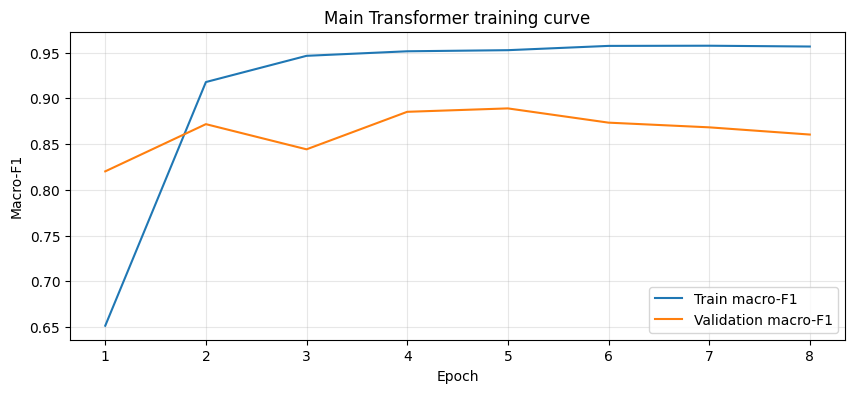

Main Transformer test accuracy: 0.8832711231761113
Main Transformer test macro-F1: 0.8829860453750684
                    precision    recall  f1-score   support

           WALKING       0.92      0.88      0.90       496
  WALKING_UPSTAIRS       0.89      0.87      0.88       471
WALKING_DOWNSTAIRS       0.84      0.97      0.90       420
           SITTING       0.84      0.78      0.81       491
          STANDING       0.81      0.86      0.84       532
            LAYING       1.00      0.95      0.97       537

          accuracy                           0.88      2947
         macro avg       0.88      0.88      0.88      2947
      weighted avg       0.89      0.88      0.88      2947



In [14]:
# =========================
# 10. Main Transformer
# =========================
main_transformer = SensorTransformer(
    input_channels=9,
    seq_len=128,
    num_classes=6,
    d_model=DEFAULT_D_MODEL,
    nhead=DEFAULT_HEADS,
    num_layers=DEFAULT_LAYERS,
    dim_feedforward=DEFAULT_DIM_FF,
    dropout=DEFAULT_DROPOUT,
    pe_type="sinusoidal",
    pooling="cls",
    patch_size=1,
)

print("Main Transformer parameters:", count_parameters(main_transformer))
main_transformer, main_history = fit_model(
    main_transformer,
    train_loader,
    val_loader,
    epochs=MAIN_EPOCHS,
    verbose=True,
)
plot_history(main_history, "Main Transformer training curve")

criterion = nn.CrossEntropyLoss()
main_test_metrics = evaluate(main_transformer, test_loader, criterion)
print("Main Transformer test accuracy:", main_test_metrics["accuracy"])
print("Main Transformer test macro-F1:", main_test_metrics["macro_f1"])
print(classification_report(main_test_metrics["y_true"], main_test_metrics["y_pred"], target_names=CLASS_NAMES))

## 10. Ablation Study - validation only

כאן אנחנו בודקים מה באמת תורם ל-Transformer.

שינוי חשוב: את ה-ablation משווים לפי **validation macro-F1 בלבד**. ה-test set נשמר לדיווח הסופי בלבד, כדי לא לבחור מודל לפי test.

שאלות:

1. האם positional encoding חשוב?
2. האם CLS token עדיף על mean pooling?
3. האם learnable positional encoding עדיף על sinusoidal?
4. האם מודל עמוק יותר באמת עוזר?
5. האם מספר attention heads משפיע?
6. האם Patch Transformer מתפקד טוב יותר/מהיר יותר?


In [15]:
# =========================
# 11. Ablation study - validation only
# =========================
ablation_configs = [
    {"name": "A1_no_pos_mean", "pe_type": "none", "pooling": "mean", "patch_size": 1, "num_layers": 2, "nhead": 4, "d_model": 64},
    {"name": "A2_sinusoidal_mean", "pe_type": "sinusoidal", "pooling": "mean", "patch_size": 1, "num_layers": 2, "nhead": 4, "d_model": 64},
    {"name": "A3_learnable_mean", "pe_type": "learnable", "pooling": "mean", "patch_size": 1, "num_layers": 2, "nhead": 4, "d_model": 64},
    {"name": "A4_sinusoidal_cls", "pe_type": "sinusoidal", "pooling": "cls", "patch_size": 1, "num_layers": 2, "nhead": 4, "d_model": 64},
    {"name": "A5_patch8_sinusoidal_cls", "pe_type": "sinusoidal", "pooling": "cls", "patch_size": 8, "num_layers": 2, "nhead": 4, "d_model": 64},
    {"name": "A6_deeper_4layers_cls", "pe_type": "sinusoidal", "pooling": "cls", "patch_size": 1, "num_layers": 4, "nhead": 4, "d_model": 64},
    {"name": "A7_more_heads_8_cls", "pe_type": "sinusoidal", "pooling": "cls", "patch_size": 1, "num_layers": 2, "nhead": 8, "d_model": 64},
]

ablation_results = []
trained_models = {"main_transformer": main_transformer}

for cfg in ablation_configs:
    print("\n" + "=" * 80)
    print("Running", cfg["name"])
    print(cfg)
    print("=" * 80)

    model = SensorTransformer(
        input_channels=9,
        seq_len=128,
        num_classes=6,
        d_model=cfg["d_model"],
        nhead=cfg["nhead"],
        num_layers=cfg["num_layers"],
        dim_feedforward=128,
        dropout=DEFAULT_DROPOUT,
        pe_type=cfg["pe_type"],
        pooling=cfg["pooling"],
        patch_size=cfg["patch_size"],
    )
    model, hist = fit_model(model, train_loader, val_loader, epochs=ABLATION_EPOCHS, verbose=False)
    val_metrics = evaluate(model, val_loader, criterion)

    result = {
        "name": cfg["name"],
        "pe_type": cfg["pe_type"],
        "pooling": cfg["pooling"],
        "patch_size": cfg["patch_size"],
        "num_layers": cfg["num_layers"],
        "nhead": cfg["nhead"],
        "d_model": cfg["d_model"],
        "params": count_parameters(model),
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
    }
    ablation_results.append(result)
    trained_models[cfg["name"]] = model
    print(pd.Series(result))

ablation_df = pd.DataFrame(ablation_results).sort_values("val_macro_f1", ascending=False)
ablation_df



Running A1_no_pos_mean
{'name': 'A1_no_pos_mean', 'pe_type': 'none', 'pooling': 'mean', 'patch_size': 1, 'num_layers': 2, 'nhead': 4, 'd_model': 64}
name            A1_no_pos_mean
pe_type                   none
pooling                   mean
patch_size                   1
num_layers                   2
nhead                        4
d_model                     64
params                   68102
val_accuracy          0.913832
val_macro_f1          0.914598
dtype: object

Running A2_sinusoidal_mean
{'name': 'A2_sinusoidal_mean', 'pe_type': 'sinusoidal', 'pooling': 'mean', 'patch_size': 1, 'num_layers': 2, 'nhead': 4, 'd_model': 64}
name            A2_sinusoidal_mean
pe_type                 sinusoidal
pooling                       mean
patch_size                       1
num_layers                       2
nhead                            4
d_model                         64
params                       68102
val_accuracy               0.90873
val_macro_f1              0.909279
dtype: objec

,name,pe_type,pooling,patch_size,num_layers,nhead,d_model,params,val_accuracy,val_macro_f1
5,A6_deeper_4layers_cls,sinusoidal,cls,1,4,4,64,135110,0.922336,0.922991
4,A5_patch8_sinusoidal_cls,sinusoidal,cls,8,2,4,64,72198,0.915533,0.922126
0,A1_no_pos_mean,none,mean,1,2,4,64,68102,0.913832,0.914598
1,A2_sinusoidal_mean,sinusoidal,mean,1,2,4,64,68102,0.908730,0.909279
2,A3_learnable_mean,learnable,mean,1,2,4,64,76294,0.904762,0.907214
3,A4_sinusoidal_cls,sinusoidal,cls,1,2,4,64,68166,0.896259,0.895446
6,A7_more_heads_8_cls,sinusoidal,cls,1,2,8,64,68166,0.886054,0.890102


In [16]:
# Validation-only model-selection summary
selection_rows = [{
    "name": "Main Transformer - raw sequence, sinusoidal PE, CLS",
    "params": count_parameters(main_transformer),
    "val_accuracy": evaluate(main_transformer, val_loader, criterion)["accuracy"],
    "val_macro_f1": evaluate(main_transformer, val_loader, criterion)["macro_f1"],
}]
selection_df = pd.concat([pd.DataFrame(selection_rows), ablation_df], ignore_index=True)
selection_df = selection_df.sort_values("val_macro_f1", ascending=False)
selection_df


,name,params,val_accuracy,val_macro_f1,pe_type,pooling,patch_size,num_layers,nhead,d_model
1,A6_deeper_4layers_cls,135110,0.922336,0.922991,sinusoidal,cls,1.0,4.0,4.0,64.0
2,A5_patch8_sinusoidal_cls,72198,0.915533,0.922126,sinusoidal,cls,8.0,2.0,4.0,64.0
3,A1_no_pos_mean,68102,0.913832,0.914598,none,mean,1.0,2.0,4.0,64.0
4,A2_sinusoidal_mean,68102,0.908730,0.909279,sinusoidal,mean,1.0,2.0,4.0,64.0
5,A3_learnable_mean,76294,0.904762,0.907214,learnable,mean,1.0,2.0,4.0,64.0
6,A4_sinusoidal_cls,68166,0.896259,0.895446,sinusoidal,cls,1.0,2.0,4.0,64.0
7,A7_more_heads_8_cls,68166,0.886054,0.890102,sinusoidal,cls,1.0,2.0,8.0,64.0
0,"Main Transformer - raw sequence, sinusoidal PE...",68166,0.893991,0.888984,NaN,NaN,NaN,NaN,NaN,NaN


## 11. Plot ablation results

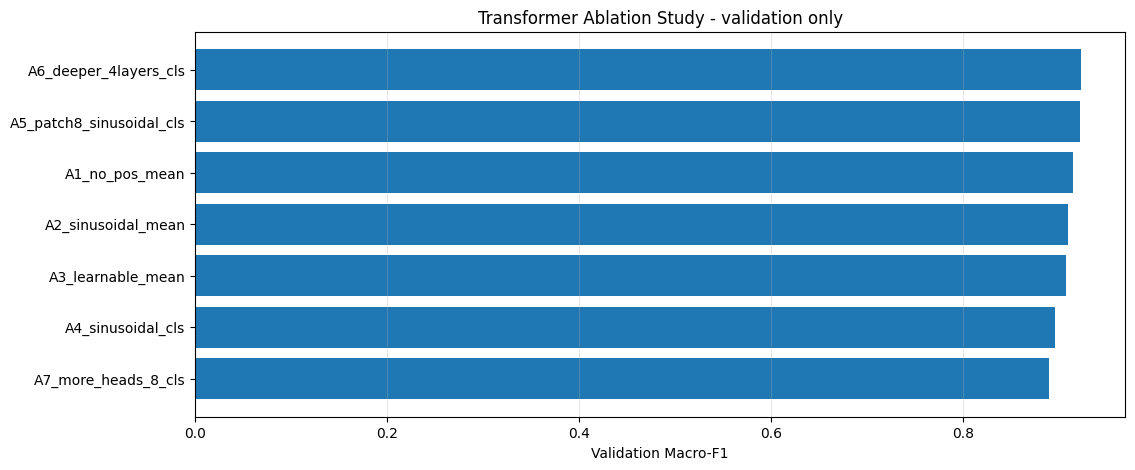

In [17]:
plt.figure(figsize=(12, 5))
plot_df = ablation_df.sort_values("val_macro_f1", ascending=True)
plt.barh(plot_df["name"], plot_df["val_macro_f1"])
plt.xlabel("Validation Macro-F1")
plt.title("Transformer Ablation Study - validation only")
plt.grid(True, axis="x", alpha=0.3)
plt.show()


## 12. Attention visualization

ננתח attention של מודל עם CLS token.

כאשר יש CLS token, אפשר לבדוק כמה ה-CLS token "מסתכל" על כל timestep או patch לפני ההחלטה.

פירוש אפשרי:

- WALKING: attention מחזורי יחסית בגלל צעדים.
- SITTING/STANDING: attention מפוזר או יציב יותר.
- WALKING_UPSTAIRS/DOWNSTAIRS: attention סביב שינויי תאוצה חזקים יותר.

True: WALKING
Pred: WALKING
Confidence: 0.99603456


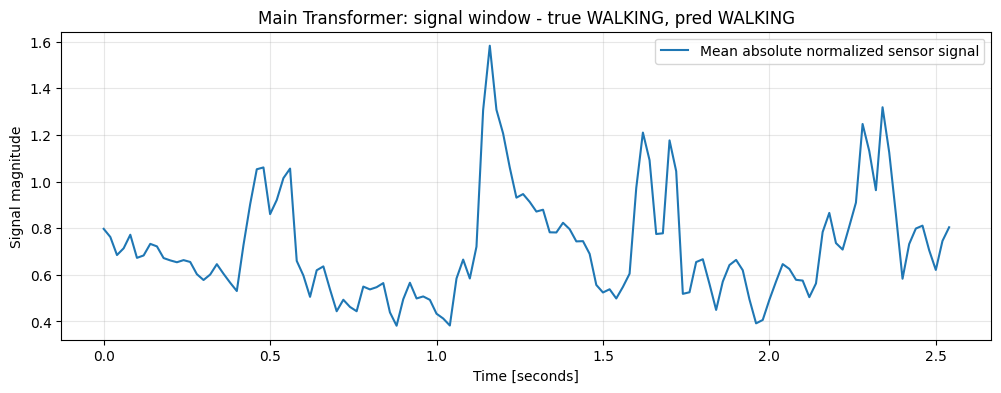

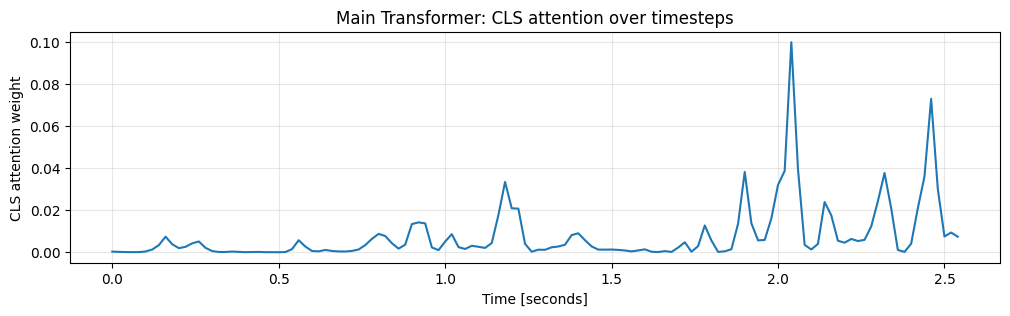

True: SITTING
Pred: STANDING
Confidence: 0.8466191


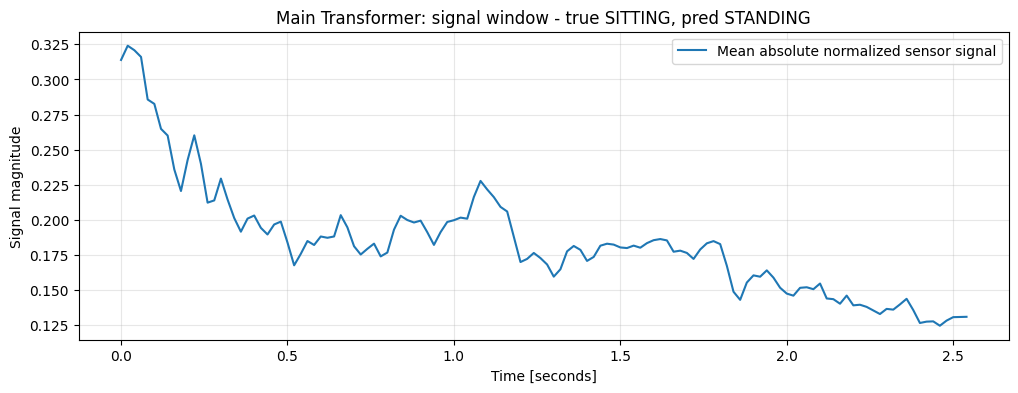

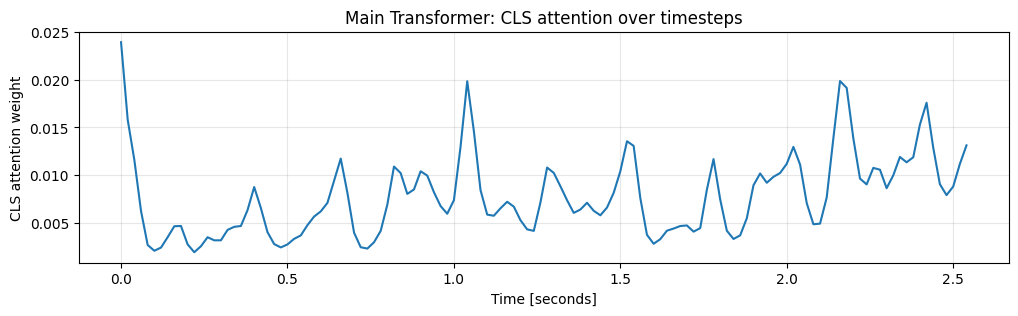

True: LAYING
Pred: LAYING
Confidence: 0.99822325


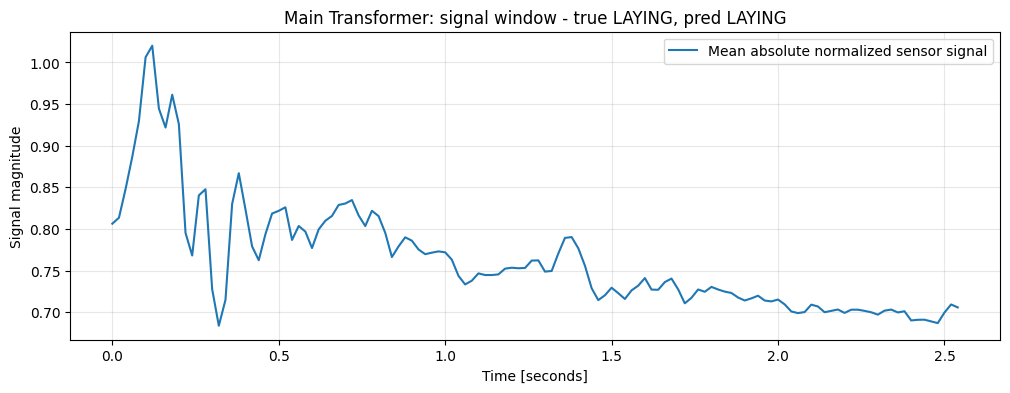

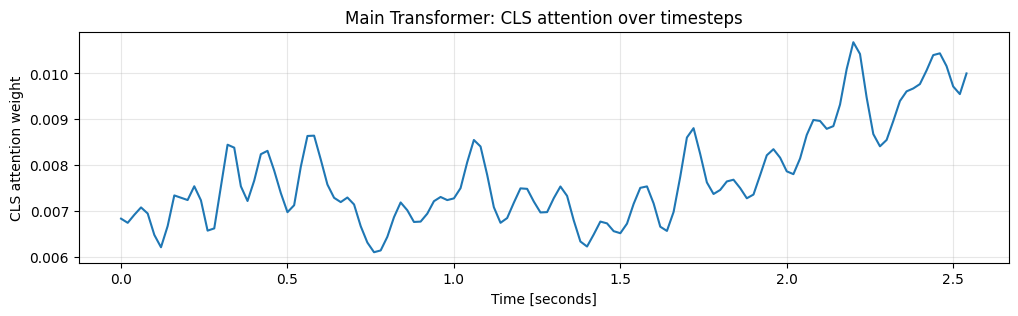

In [18]:
# =========================
# 12. Attention visualization
# =========================
@torch.no_grad()
def get_single_prediction_with_attention(model: SensorTransformer, X_np: np.ndarray, idx: int):
    model.eval()
    x = torch.tensor(X_np[idx:idx+1], dtype=torch.float32).to(device)
    logits, attn_list = model(x, return_attn=True)
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred = int(probs.argmax())
    return pred, probs, attn_list


def extract_cls_attention(attn_list: List[torch.Tensor], patch_size: int = 1) -> np.ndarray:
    """
    Returns CLS attention over tokens from last layer.
    Shape returned: num_tokens.
    """
    last_attn = attn_list[-1].cpu().numpy()  # B x heads x query_len x key_len
    # CLS query attends to all keys. Remove CLS key itself.
    cls_to_tokens = last_attn[0, :, 0, 1:]  # heads x tokens
    return cls_to_tokens.mean(axis=0)


def plot_attention_for_sample(
    model: SensorTransformer,
    X_np: np.ndarray,
    y_np: np.ndarray,
    idx: int,
    title_prefix: str = "Attention",
):
    pred, probs, attn_list = get_single_prediction_with_attention(model, X_np, idx)
    patch_size = model.patch_size
    attn = extract_cls_attention(attn_list, patch_size=patch_size)

    # Raw magnitude summary from normalized channels
    raw = X_np[idx]
    magnitude = np.mean(np.abs(raw), axis=1)
    time_sec = np.arange(raw.shape[0]) / 50.0

    if patch_size > 1:
        token_time = (np.arange(len(attn)) * patch_size + patch_size / 2) / 50.0
    else:
        token_time = time_sec

    print("True:", CLASS_NAMES[y_np[idx]])
    print("Pred:", CLASS_NAMES[pred])
    print("Confidence:", probs[pred])

    plt.figure(figsize=(12, 4))
    plt.plot(time_sec, magnitude, label="Mean absolute normalized sensor signal")
    plt.xlabel("Time [seconds]")
    plt.ylabel("Signal magnitude")
    plt.title(f"{title_prefix}: signal window - true {CLASS_NAMES[y_np[idx]]}, pred {CLASS_NAMES[pred]}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 3))
    plt.plot(token_time, attn, marker="o" if patch_size > 1 else None)
    plt.xlabel("Time [seconds]")
    plt.ylabel("CLS attention weight")
    plt.title(f"{title_prefix}: CLS attention over {'patches' if patch_size > 1 else 'timesteps'}")
    plt.grid(True, alpha=0.3)
    plt.show()


def find_first_index_by_class(y_np: np.ndarray, class_id: int) -> int:
    return int(np.where(y_np == class_id)[0][0])

# Use a CLS model for attention. Main transformer is CLS by default.
for class_id in [0, 3, 5]:  # WALKING, SITTING, LAYING
    idx = find_first_index_by_class(y_test, class_id)
    plot_attention_for_sample(main_transformer, X_test_raw_scaled, y_test, idx, title_prefix="Main Transformer")

## 13. Attention heatmap per head

כאן רואים את מפת ה-attention של layer האחרון. זה פחות "עסקי" אבל טוב טכנית לפרויקט.

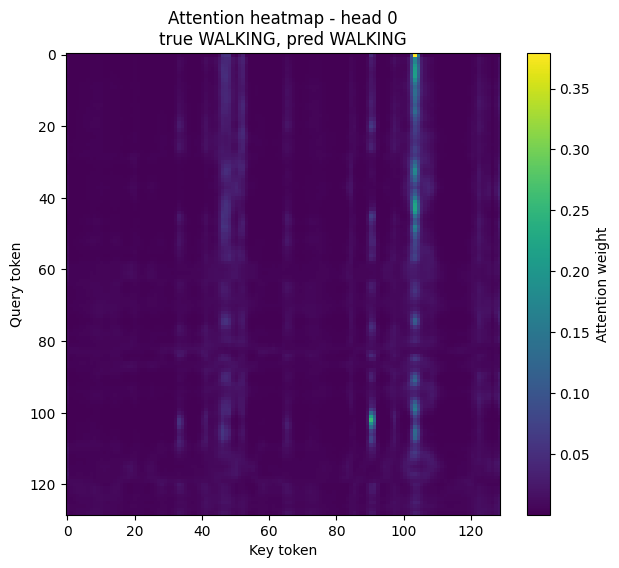

In [19]:
def plot_attention_heatmap(model: SensorTransformer, X_np: np.ndarray, y_np: np.ndarray, idx: int, head: int = 0):
    pred, probs, attn_list = get_single_prediction_with_attention(model, X_np, idx)
    last_attn = attn_list[-1].cpu().numpy()[0]  # heads x query_len x key_len
    head = min(head, last_attn.shape[0] - 1)
    mat = last_attn[head]

    plt.figure(figsize=(7, 6))
    plt.imshow(mat, aspect="auto")
    plt.colorbar(label="Attention weight")
    plt.title(
        f"Attention heatmap - head {head}\n"
        f"true {CLASS_NAMES[y_np[idx]]}, pred {CLASS_NAMES[pred]}"
    )
    plt.xlabel("Key token")
    plt.ylabel("Query token")
    plt.show()

idx = find_first_index_by_class(y_test, 0)  # WALKING
plot_attention_heatmap(main_transformer, X_test_raw_scaled, y_test, idx, head=0)

## 14. Error analysis

נבדוק איפה המודל מתבלבל.

ב-HAR בדרך כלל בלבול נפוץ:

- SITTING מול STANDING
- WALKING_UPSTAIRS מול WALKING_DOWNSTAIRS

כי אלו פעילויות קרובות מבחינת סיגנל.

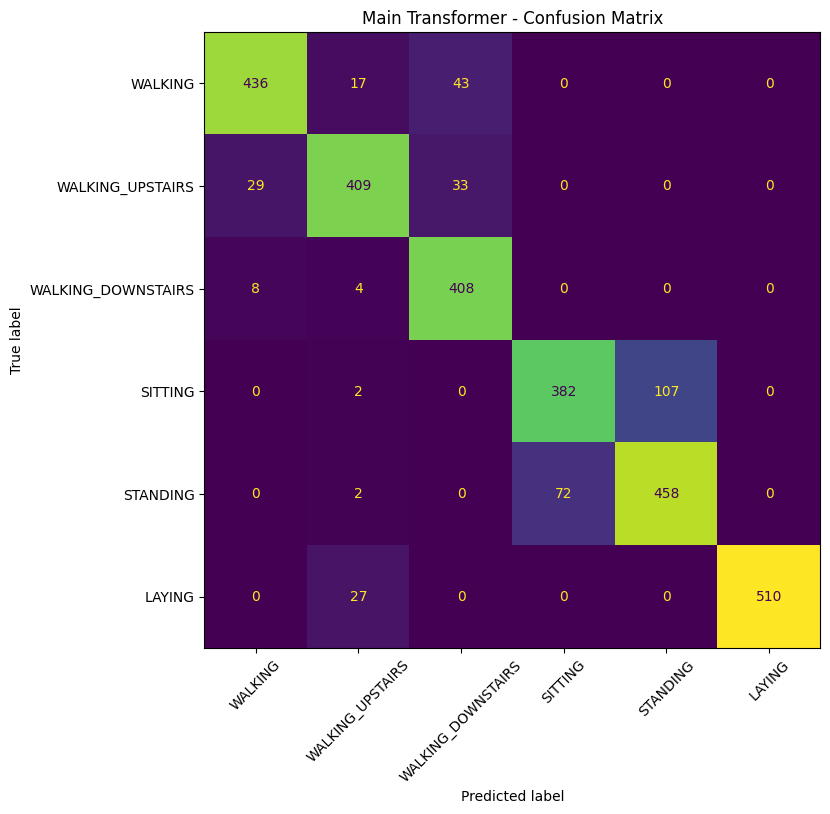

Number of test errors: 344 out of 2947


,test_index,subject,true_label,pred_label,confidence
255,1177,10,WALKING_UPSTAIRS,WALKING_DOWNSTAIRS,0.995080
283,1453,12,WALKING,WALKING_DOWNSTAIRS,0.994380
173,1066,10,STANDING,SITTING,0.992221
293,1464,12,WALKING,WALKING_DOWNSTAIRS,0.992128
298,1470,12,WALKING,WALKING_DOWNSTAIRS,0.991960
174,1067,10,STANDING,SITTING,0.991940
172,1065,10,STANDING,SITTING,0.991931
263,1185,10,WALKING_UPSTAIRS,WALKING_DOWNSTAIRS,0.991689
302,1474,12,WALKING,WALKING_DOWNSTAIRS,0.991576
178,1071,10,STANDING,SITTING,0.991449


In [20]:
# =========================
# 14. Error analysis
# =========================
y_true = main_test_metrics["y_true"]
y_pred = main_test_metrics["y_pred"]
probs = main_test_metrics["probs"]

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(9, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Main Transformer - Confusion Matrix")
plt.show()

errors = np.where(y_true != y_pred)[0]
error_df = pd.DataFrame({
    "test_index": errors,
    "subject": subject_test[errors],
    "true_label": [CLASS_NAMES[i] for i in y_true[errors]],
    "pred_label": [CLASS_NAMES[i] for i in y_pred[errors]],
    "confidence": probs[errors].max(axis=1),
})

print("Number of test errors:", len(error_df), "out of", len(y_true))
error_df.sort_values("confidence", ascending=False).head(20)

In [21]:
# Analyze confusion pairs
pair_counts = (
    error_df.groupby(["true_label", "pred_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
pair_counts.head(20)

,true_label,pred_label,count
1,SITTING,STANDING,107
3,STANDING,SITTING,72
5,WALKING,WALKING_DOWNSTAIRS,43
10,WALKING_UPSTAIRS,WALKING_DOWNSTAIRS,33
9,WALKING_UPSTAIRS,WALKING,29
0,LAYING,WALKING_UPSTAIRS,27
6,WALKING,WALKING_UPSTAIRS,17
7,WALKING_DOWNSTAIRS,WALKING,8
8,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS,4
2,SITTING,WALKING_UPSTAIRS,2


## 14.1 Per-subject error analysis

כאן נבדוק אילו נבדקים היו קשים יותר למודל. זה חשוב כי ב-HAR יש שונות בין אנשים: גובה, קצב הליכה, מיקום הטלפון וצורת תנועה.


In [22]:
# =========================
# 14.1 Per-subject analysis
# =========================
def per_subject_analysis(y_true: np.ndarray, y_pred: np.ndarray, subjects: np.ndarray) -> pd.DataFrame:
    rows = []
    for subject in sorted(np.unique(subjects)):
        mask = subjects == subject
        yt, yp = y_true[mask], y_pred[mask]
        acc = accuracy_score(yt, yp)
        macro = f1_score(yt, yp, average="macro")
        err_mask = yt != yp
        if err_mask.sum() > 0:
            tmp = pd.DataFrame({
                "true": [CLASS_NAMES[i] for i in yt[err_mask]],
                "pred": [CLASS_NAMES[i] for i in yp[err_mask]],
            })
            common_error = tmp.groupby(["true", "pred"]).size().sort_values(ascending=False).index[0]
            common_error = f"{common_error[0]} -> {common_error[1]}"
        else:
            common_error = "None"
        rows.append({
            "subject": int(subject),
            "n_windows": int(mask.sum()),
            "accuracy": acc,
            "macro_f1": macro,
            "n_errors": int(err_mask.sum()),
            "most_common_error": common_error,
        })
    return pd.DataFrame(rows).sort_values("accuracy")

subject_perf_df = per_subject_analysis(y_true, y_pred, subject_test)
subject_perf_df


,subject,n_windows,accuracy,macro_f1,n_errors,most_common_error
3,10,294,0.561224,0.557009,129,SITTING -> STANDING
2,9,288,0.649306,0.617211,101,STANDING -> SITTING
0,2,302,0.874172,0.847152,38,SITTING -> STANDING
4,12,320,0.925000,0.915067,24,WALKING -> WALKING_DOWNSTAIRS
6,18,364,0.956044,0.955696,16,SITTING -> STANDING
5,13,327,0.957187,0.954437,14,SITTING -> STANDING
1,4,317,0.965300,0.965109,11,STANDING -> SITTING
7,20,354,0.968927,0.972893,11,SITTING -> STANDING
8,24,381,1.000000,1.000000,0,None


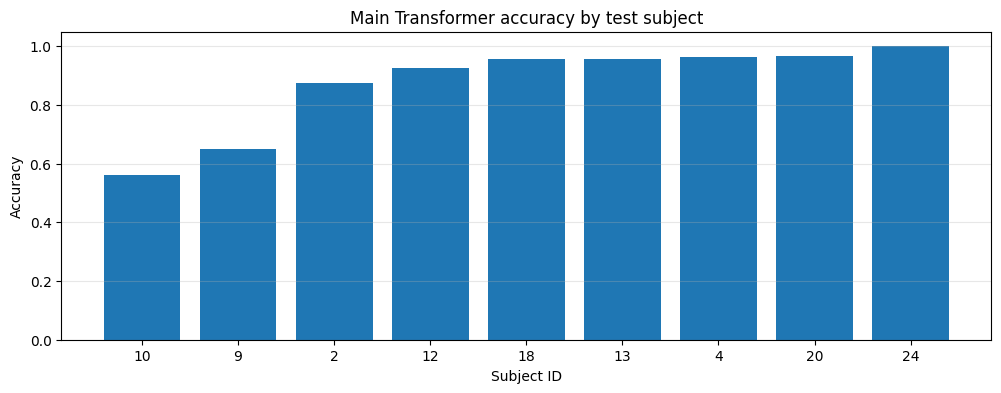

,subject,n_windows,accuracy,macro_f1,n_errors,most_common_error
3,10,294,0.561224,0.557009,129,SITTING -> STANDING
2,9,288,0.649306,0.617211,101,STANDING -> SITTING
0,2,302,0.874172,0.847152,38,SITTING -> STANDING
4,12,320,0.925000,0.915067,24,WALKING -> WALKING_DOWNSTAIRS
6,18,364,0.956044,0.955696,16,SITTING -> STANDING
5,13,327,0.957187,0.954437,14,SITTING -> STANDING
1,4,317,0.965300,0.965109,11,STANDING -> SITTING
7,20,354,0.968927,0.972893,11,SITTING -> STANDING
8,24,381,1.000000,1.000000,0,None


In [23]:
plt.figure(figsize=(12, 4))
plot_df = subject_perf_df.sort_values("accuracy")
plt.bar(plot_df["subject"].astype(str), plot_df["accuracy"])
plt.xlabel("Subject ID")
plt.ylabel("Accuracy")
plt.title("Main Transformer accuracy by test subject")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

subject_perf_df.head(10)


## 14.2 Confidence and calibration analysis

דיוק גבוה לא מספיק. בפרויקט תעשייתי חשוב לבדוק האם confidence של המודל אמין. אם המודל טועה עם confidence גבוה, זה סימן ל-overconfidence.

נחשב Expected Calibration Error בצורה פשוטה ונציג reliability table.


In [24]:
# =========================
# 14.2 Calibration and confidence analysis
# =========================
def calibration_table(y_true: np.ndarray, y_pred: np.ndarray, probs: np.ndarray, n_bins: int = 10) -> Tuple[pd.DataFrame, float]:
    confidences = probs.max(axis=1)
    correct = (y_true == y_pred).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    rows = []
    ece = 0.0
    n = len(y_true)

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i == n_bins - 1:
            mask = (confidences >= lo) & (confidences <= hi)
        else:
            mask = (confidences >= lo) & (confidences < hi)
        count = int(mask.sum())
        if count == 0:
            acc = np.nan
            avg_conf = np.nan
        else:
            acc = float(correct[mask].mean())
            avg_conf = float(confidences[mask].mean())
            ece += (count / n) * abs(acc - avg_conf)
        rows.append({
            "bin_low": lo,
            "bin_high": hi,
            "count": count,
            "accuracy": acc,
            "avg_confidence": avg_conf,
            "abs_gap": np.nan if count == 0 else abs(acc - avg_conf),
        })
    return pd.DataFrame(rows), float(ece)

cal_df, ece = calibration_table(y_true, y_pred, probs, n_bins=10)
print("Expected Calibration Error (ECE):", round(ece, 4))
cal_df


Expected Calibration Error (ECE): 0.047


,bin_low,bin_high,count,accuracy,avg_confidence,abs_gap
0,0.0,0.1,0,NaN,NaN,NaN
1,0.1,0.2,0,NaN,NaN,NaN
2,0.2,0.3,0,NaN,NaN,NaN
3,0.3,0.4,0,NaN,NaN,NaN
4,0.4,0.5,9,0.333333,0.480923,0.147589
5,0.5,0.6,115,0.486957,0.551316,0.064360
6,0.6,0.7,110,0.345455,0.643890,0.298436
7,0.7,0.8,114,0.719298,0.750685,0.031387
8,0.8,0.9,256,0.707031,0.856347,0.149316
9,0.9,1.0,2343,0.957320,0.980906,0.023587


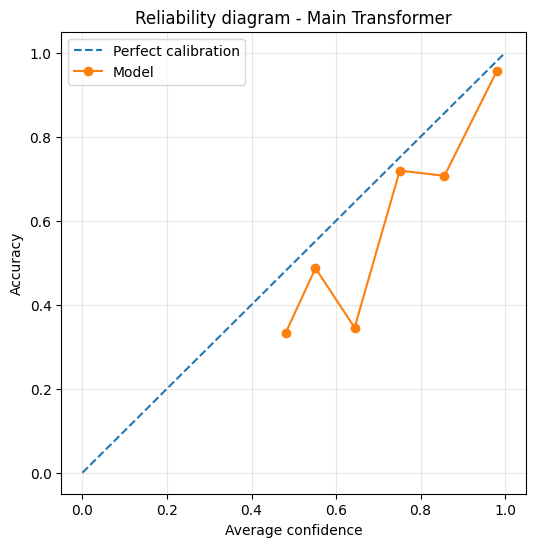

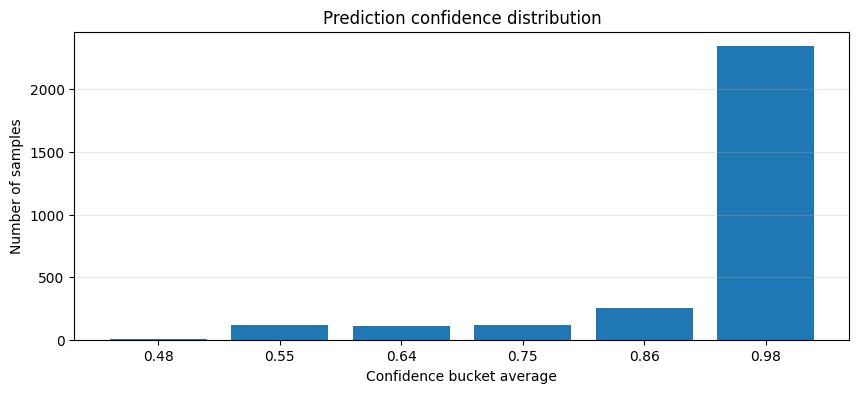

In [25]:
valid = cal_df[cal_df["count"] > 0].copy()
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.plot(valid["avg_confidence"], valid["accuracy"], marker="o", label="Model")
plt.xlabel("Average confidence")
plt.ylabel("Accuracy")
plt.title("Reliability diagram - Main Transformer")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(valid["avg_confidence"].round(2).astype(str), valid["count"])
plt.xlabel("Confidence bucket average")
plt.ylabel("Number of samples")
plt.title("Prediction confidence distribution")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


### Visualize high-confidence mistakes

זה טוב להצגה: מראים שהמודל לא רק טועה, אלא גם למה ייתכן שזה קרה לפי הסיגנל.

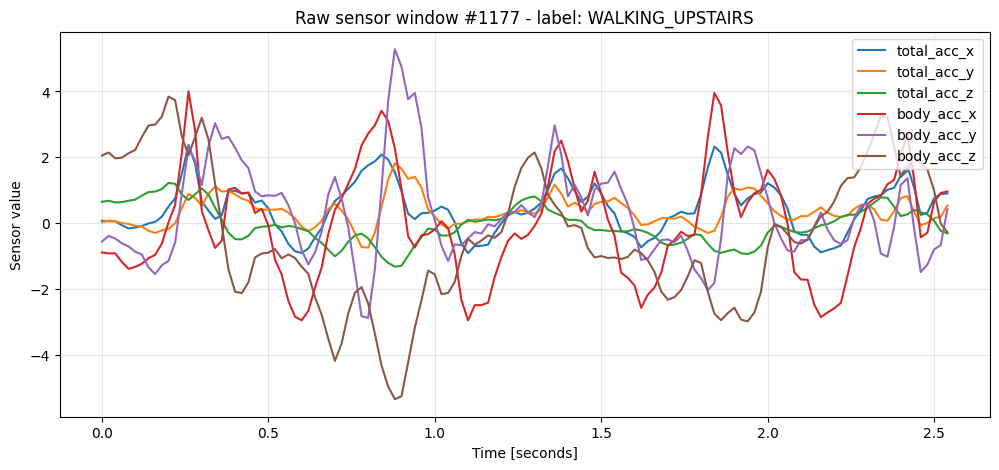

True: WALKING_UPSTAIRS
Pred: WALKING_DOWNSTAIRS
Confidence: 0.99508035


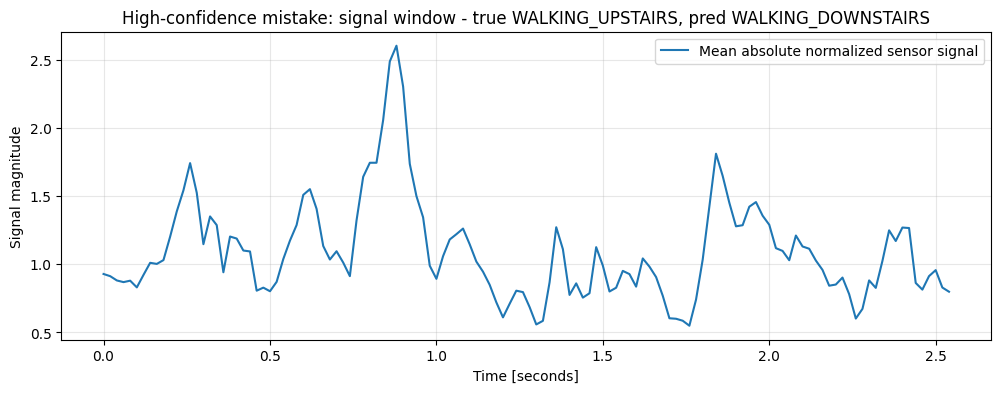

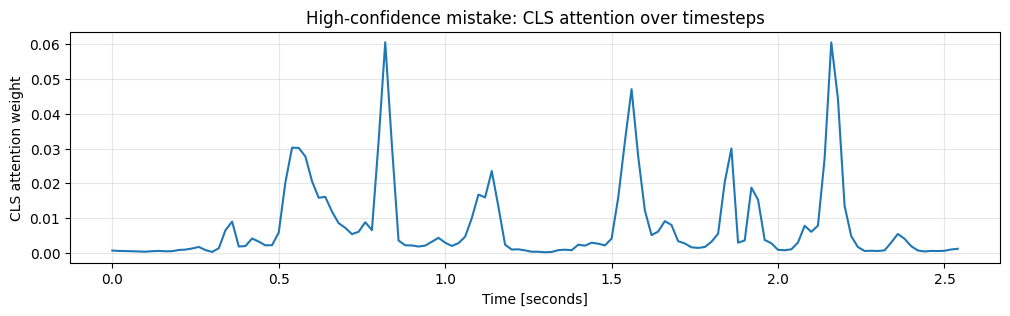

In [26]:
if len(error_df) > 0:
    top_error_idx = int(error_df.sort_values("confidence", ascending=False).iloc[0]["test_index"])
    plot_raw_window(X_test_raw_scaled, y_test, idx=top_error_idx)
    plot_attention_for_sample(main_transformer, X_test_raw_scaled, y_test, top_error_idx, title_prefix="High-confidence mistake")
else:
    print("No errors found for the main Transformer.")

## 15. Patch Transformer deep dive

Patch Transformer משנה את ההגדרה של token:

```text
Time-step Transformer: 128 tokens, each token = 9 sensor values
Patch Transformer: 16 tokens, each token = 8 timesteps x 9 channels = 72 values
```

למה זה מעניין?

בסיגנלים, לפעמים pattern מקומי קצר חשוב יותר מנקודת זמן אחת. Patch Transformer יכול ללמוד תבניות קצרות בצורה יעילה יותר.

Patch Transformer parameters: 72198
Epoch 01/8 | train loss 0.7725 acc 0.7282 f1 0.7246 | val loss 0.2897 acc 0.9144 f1 0.9142
Epoch 02/8 | train loss 0.2048 acc 0.9309 f1 0.9325 | val loss 0.2919 acc 0.8866 f1 0.8911
Epoch 03/8 | train loss 0.1462 acc 0.9460 f1 0.9484 | val loss 0.2578 acc 0.9048 f1 0.9072
Epoch 04/8 | train loss 0.1304 acc 0.9497 f1 0.9522 | val loss 0.2463 acc 0.8946 f1 0.9004
Epoch 05/8 | train loss 0.1199 acc 0.9510 f1 0.9536 | val loss 0.2333 acc 0.9257 f1 0.9283
Epoch 06/8 | train loss 0.1134 acc 0.9531 f1 0.9557 | val loss 0.2517 acc 0.8917 f1 0.8975
Epoch 07/8 | train loss 0.1099 acc 0.9547 f1 0.9573 | val loss 0.2561 acc 0.8861 f1 0.8928
Epoch 08/8 | train loss 0.1107 acc 0.9529 f1 0.9556 | val loss 0.2463 acc 0.8997 f1 0.9056


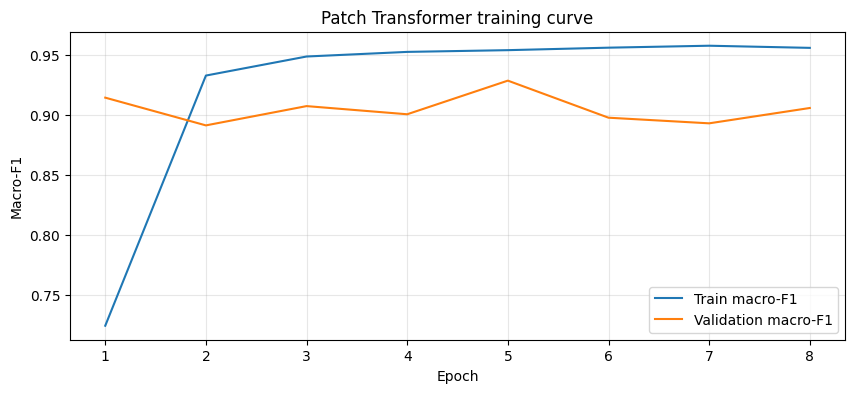

Patch Transformer test accuracy: 0.8958262639972854
Patch Transformer test macro-F1: 0.8946012680640391
                    precision    recall  f1-score   support

           WALKING       0.87      0.94      0.91       496
  WALKING_UPSTAIRS       0.95      0.83      0.88       471
WALKING_DOWNSTAIRS       0.89      0.95      0.92       420
           SITTING       0.87      0.77      0.81       491
          STANDING       0.81      0.89      0.85       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.90      2947
         macro avg       0.90      0.90      0.89      2947
      weighted avg       0.90      0.90      0.90      2947



In [27]:
# =========================
# 15. Dedicated Patch Transformer experiment
# =========================
patch_transformer = SensorTransformer(
    input_channels=9,
    seq_len=128,
    num_classes=6,
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=DEFAULT_DROPOUT,
    pe_type="sinusoidal",
    pooling="cls",
    patch_size=8,
)

print("Patch Transformer parameters:", count_parameters(patch_transformer))
patch_transformer, patch_history = fit_model(
    patch_transformer,
    train_loader,
    val_loader,
    epochs=PATCH_EPOCHS,
    verbose=True,
)
plot_history(patch_history, "Patch Transformer training curve")

patch_test_metrics = evaluate(patch_transformer, test_loader, criterion)
print("Patch Transformer test accuracy:", patch_test_metrics["accuracy"])
print("Patch Transformer test macro-F1:", patch_test_metrics["macro_f1"])
print(classification_report(patch_test_metrics["y_true"], patch_test_metrics["y_pred"], target_names=CLASS_NAMES))

True: WALKING
Pred: WALKING
Confidence: 0.9958301


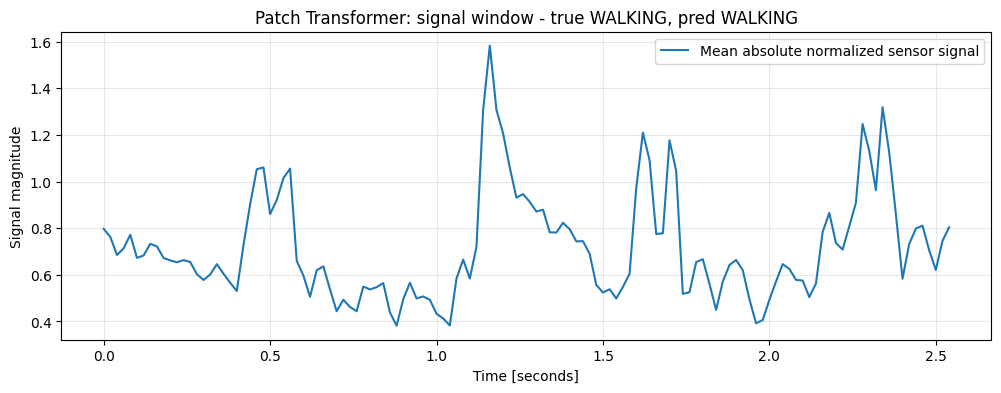

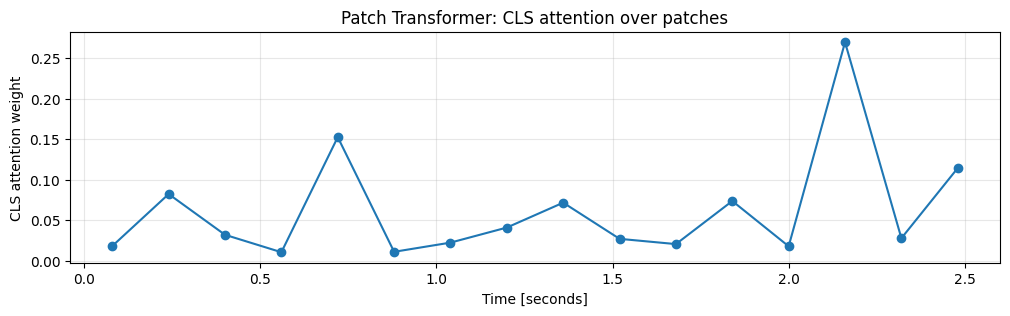

In [28]:
# Compare attention on patch model for a WALKING sample
idx = find_first_index_by_class(y_test, 0)
plot_attention_for_sample(patch_transformer, X_test_raw_scaled, y_test, idx, title_prefix="Patch Transformer")

## 16. CNN-Transformer Hybrid experiment

זה המודל ההיברידי שהוספנו: שכבות Conv1D לפני Transformer. המטרה היא לבדוק האם feature extraction מקומי עוזר ל-Transformer על סיגנלי חיישנים.


CNN-Transformer parameters: 79494
Epoch 01/8 | train loss 0.6444 acc 0.7725 f1 0.7688 | val loss 0.3271 acc 0.9082 f1 0.9056
Epoch 02/8 | train loss 0.1492 acc 0.9476 f1 0.9501 | val loss 0.2663 acc 0.9223 f1 0.9268
Epoch 03/8 | train loss 0.1230 acc 0.9531 f1 0.9558 | val loss 0.2766 acc 0.8889 f1 0.8965
Epoch 04/8 | train loss 0.1118 acc 0.9553 f1 0.9577 | val loss 0.2571 acc 0.8963 f1 0.9017
Epoch 05/8 | train loss 0.1037 acc 0.9583 f1 0.9606 | val loss 0.2768 acc 0.9031 f1 0.9083
Epoch 06/8 | train loss 0.1061 acc 0.9592 f1 0.9616 | val loss 0.2604 acc 0.9031 f1 0.9091
Epoch 07/8 | train loss 0.0998 acc 0.9605 f1 0.9628 | val loss 0.2599 acc 0.9036 f1 0.9099
Epoch 08/8 | train loss 0.0986 acc 0.9628 f1 0.9650 | val loss 0.2603 acc 0.9042 f1 0.9103


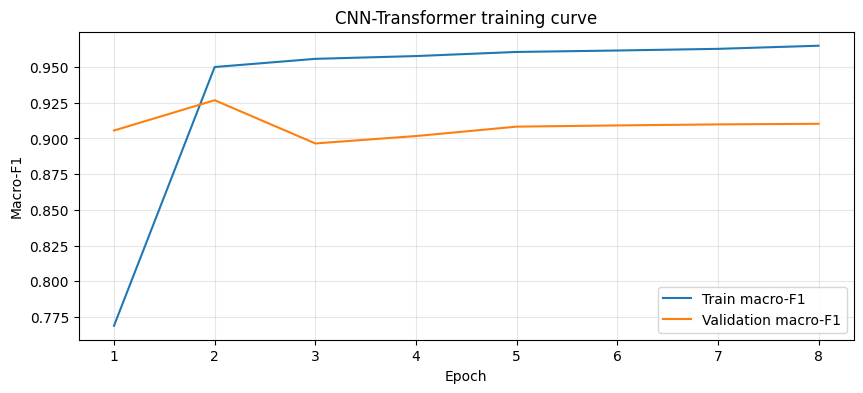

CNN-Transformer test accuracy: 0.9090600610790635
CNN-Transformer test macro-F1: 0.9102247336088215
                    precision    recall  f1-score   support

           WALKING       0.95      0.98      0.97       496
  WALKING_UPSTAIRS       0.96      0.91      0.93       471
WALKING_DOWNSTAIRS       0.93      0.96      0.94       420
           SITTING       0.89      0.74      0.81       491
          STANDING       0.76      0.91      0.83       532
            LAYING       1.00      0.95      0.97       537

          accuracy                           0.91      2947
         macro avg       0.92      0.91      0.91      2947
      weighted avg       0.91      0.91      0.91      2947



In [29]:
# =========================
# 16. CNN-Transformer Hybrid experiment
# =========================
cnn_transformer = CNNTransformerClassifier(
    input_channels=9,
    seq_len=128,
    num_classes=6,
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=DEFAULT_DROPOUT,
    pe_type="sinusoidal",
    pooling="cls",
    conv_kernel_size=5,
)

print("CNN-Transformer parameters:", count_parameters(cnn_transformer))
cnn_transformer, cnn_history = fit_model(
    cnn_transformer,
    train_loader,
    val_loader,
    epochs=CNN_TRANSFORMER_EPOCHS,
    verbose=True,
)
plot_history(cnn_history, "CNN-Transformer training curve")

cnn_test_metrics = evaluate(cnn_transformer, test_loader, criterion)
print("CNN-Transformer test accuracy:", cnn_test_metrics["accuracy"])
print("CNN-Transformer test macro-F1:", cnn_test_metrics["macro_f1"])
print(classification_report(cnn_test_metrics["y_true"], cnn_test_metrics["y_pred"], target_names=CLASS_NAMES))


## 17. Sensor ablation

כאן נבדוק אילו ערוצי חיישנים הכי חשובים. זה מתחבר ישירות לשאלה המחקרית: האם צריך acceleration, gyroscope, או שילוב שלהם?

הניסוי משתמש באותו subject-wise train/validation split. לצורך model selection נשווה לפי validation, ובסוף נדווח גם test כדי להבין generalization.


In [30]:
# =========================
# 17. Sensor ablation
# =========================
def make_channel_loaders(channel_indices: List[int]) -> Tuple[DataLoader, DataLoader, DataLoader]:
    Xtr = X_train_raw_scaled[:, :, channel_indices]
    Xte = X_test_raw_scaled[:, :, channel_indices]
    full = HARRawDataset(Xtr, y_train, subject_train)
    tr = Subset(full, train_indices.tolist())
    va = Subset(full, val_indices.tolist())
    te = HARRawDataset(Xte, y_test, subject_test)
    return (
        DataLoader(tr, batch_size=BATCH_SIZE, shuffle=True, num_workers=0),
        DataLoader(va, batch_size=BATCH_SIZE, shuffle=False, num_workers=0),
        DataLoader(te, batch_size=BATCH_SIZE, shuffle=False, num_workers=0),
    )

sensor_results = []
sensor_models = {}

for group_name, channel_indices in CHANNEL_GROUPS.items():
    print("\n" + "=" * 80)
    print("Sensor ablation:", group_name, "channels:", [SIGNAL_NAMES[i] for i in channel_indices])
    print("=" * 80)
    tr_loader, va_loader, te_loader = make_channel_loaders(channel_indices)

    model = SensorTransformer(
        input_channels=len(channel_indices),
        seq_len=128,
        num_classes=6,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=DEFAULT_DROPOUT,
        pe_type="sinusoidal",
        pooling="cls",
        patch_size=1,
    )
    model, hist = fit_model(model, tr_loader, va_loader, epochs=SENSOR_ABLATION_EPOCHS, verbose=False)
    val_m = evaluate(model, va_loader, criterion)
    test_m = evaluate(model, te_loader, criterion)
    sensor_models[group_name] = model
    sensor_results.append({
        "sensor_group": group_name,
        "channels": ", ".join([SIGNAL_NAMES[i] for i in channel_indices]),
        "n_channels": len(channel_indices),
        "params": count_parameters(model),
        "val_accuracy": val_m["accuracy"],
        "val_macro_f1": val_m["macro_f1"],
        "test_accuracy": test_m["accuracy"],
        "test_macro_f1": test_m["macro_f1"],
    })

sensor_ablation_df = pd.DataFrame(sensor_results).sort_values("val_macro_f1", ascending=False)
sensor_ablation_df



Sensor ablation: all_sensors channels: ['total_acc_x', 'total_acc_y', 'total_acc_z', 'body_acc_x', 'body_acc_y', 'body_acc_z', 'body_gyro_x', 'body_gyro_y', 'body_gyro_z']

Sensor ablation: acceleration_only_total_plus_body channels: ['total_acc_x', 'total_acc_y', 'total_acc_z', 'body_acc_x', 'body_acc_y', 'body_acc_z']

Sensor ablation: gyroscope_only channels: ['body_gyro_x', 'body_gyro_y', 'body_gyro_z']

Sensor ablation: total_acc_only channels: ['total_acc_x', 'total_acc_y', 'total_acc_z']

Sensor ablation: body_acc_only channels: ['body_acc_x', 'body_acc_y', 'body_acc_z']


,sensor_group,channels,n_channels,params,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1
0,all_sensors,"total_acc_x, total_acc_y, total_acc_z, body_ac...",9,68166,0.895692,0.894743,0.879539,0.878488
3,total_acc_only,"total_acc_x, total_acc_y, total_acc_z",3,67782,0.843537,0.830819,0.768239,0.761727
1,acceleration_only_total_plus_body,"total_acc_x, total_acc_y, total_acc_z, body_ac...",6,67974,0.827664,0.820436,0.811334,0.807817
2,gyroscope_only,"body_gyro_x, body_gyro_y, body_gyro_z",3,67782,0.497166,0.487316,0.452664,0.427017
4,body_acc_only,"body_acc_x, body_acc_y, body_acc_z",3,67782,0.522676,0.481050,0.546318,0.481915


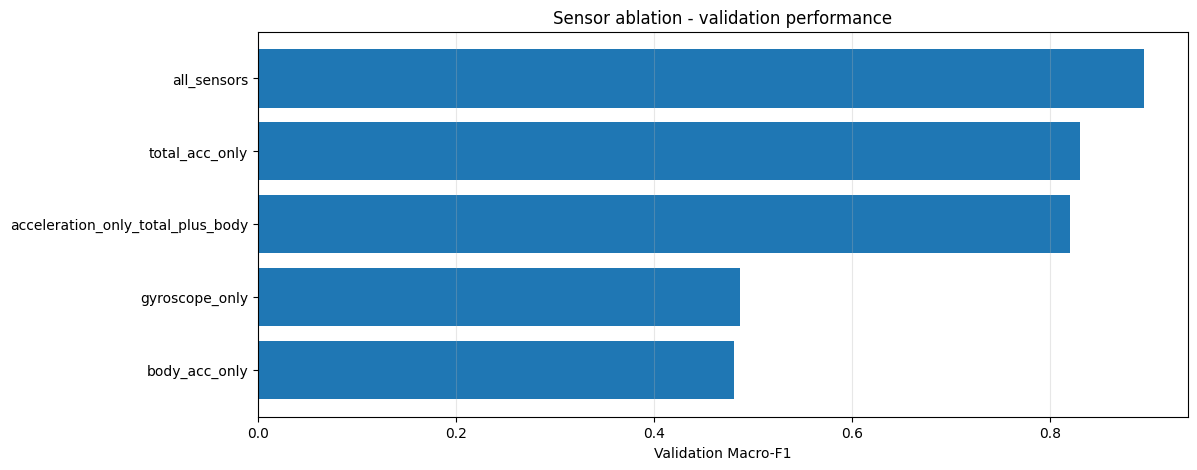

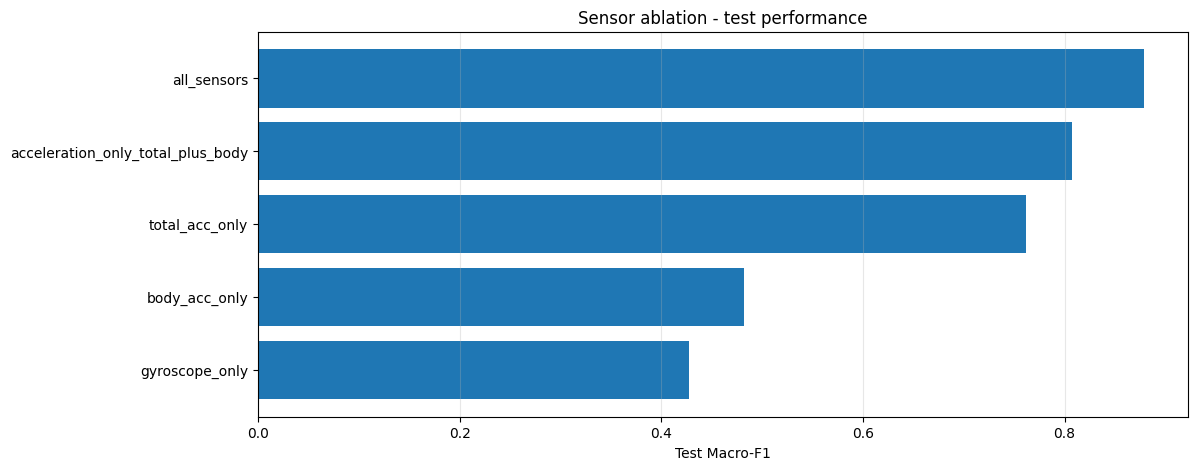

In [31]:
plt.figure(figsize=(12, 5))
plot_df = sensor_ablation_df.sort_values("val_macro_f1", ascending=True)
plt.barh(plot_df["sensor_group"], plot_df["val_macro_f1"])
plt.xlabel("Validation Macro-F1")
plt.title("Sensor ablation - validation performance")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

plt.figure(figsize=(12, 5))
plot_df = sensor_ablation_df.sort_values("test_macro_f1", ascending=True)
plt.barh(plot_df["sensor_group"], plot_df["test_macro_f1"])
plt.xlabel("Test Macro-F1")
plt.title("Sensor ablation - test performance")
plt.grid(True, axis="x", alpha=0.3)
plt.show()


## 18. Final comparison table

כאן מדווחים על ה-test set. עד כאן השתמשנו ב-validation לבחירת מודלים וניסויי ablation, וכעת מציגים את התוצאות הסופיות.


In [32]:
final_rows = baseline_results.copy()
final_rows.append({
    "model": "Main Transformer - timestep tokens, CLS",
    "accuracy": main_test_metrics["accuracy"],
    "macro_f1": main_test_metrics["macro_f1"],
})
final_rows.append({
    "model": "Patch Transformer - patch size 8, CLS",
    "accuracy": patch_test_metrics["accuracy"],
    "macro_f1": patch_test_metrics["macro_f1"],
})
final_rows.append({
    "model": "CNN-Transformer Hybrid - Conv1D + CLS Transformer",
    "accuracy": cnn_test_metrics["accuracy"],
    "macro_f1": cnn_test_metrics["macro_f1"],
})

# Include sensor ablation rows as secondary Transformer variants
if "sensor_ablation_df" in globals():
    for _, row in sensor_ablation_df.iterrows():
        final_rows.append({
            "model": f"Sensor ablation - {row['sensor_group']}",
            "accuracy": row["test_accuracy"],
            "macro_f1": row["test_macro_f1"],
        })

final_comparison = pd.DataFrame(final_rows).sort_values("macro_f1", ascending=False)
final_comparison


,model,accuracy,macro_f1
0,Logistic Regression - 561 engineered features,0.958602,0.958274
4,CNN-Transformer Hybrid - Conv1D + CLS Transformer,0.909060,0.910225
1,Random Forest - handcrafted time + FFT features,0.910417,0.907392
3,"Patch Transformer - patch size 8, CLS",0.895826,0.894601
2,"Main Transformer - timestep tokens, CLS",0.883271,0.882986
5,Sensor ablation - all_sensors,0.879539,0.878488
7,Sensor ablation - acceleration_only_total_plus...,0.811334,0.807817
6,Sensor ablation - total_acc_only,0.768239,0.761727
9,Sensor ablation - body_acc_only,0.546318,0.481915
8,Sensor ablation - gyroscope_only,0.452664,0.427017


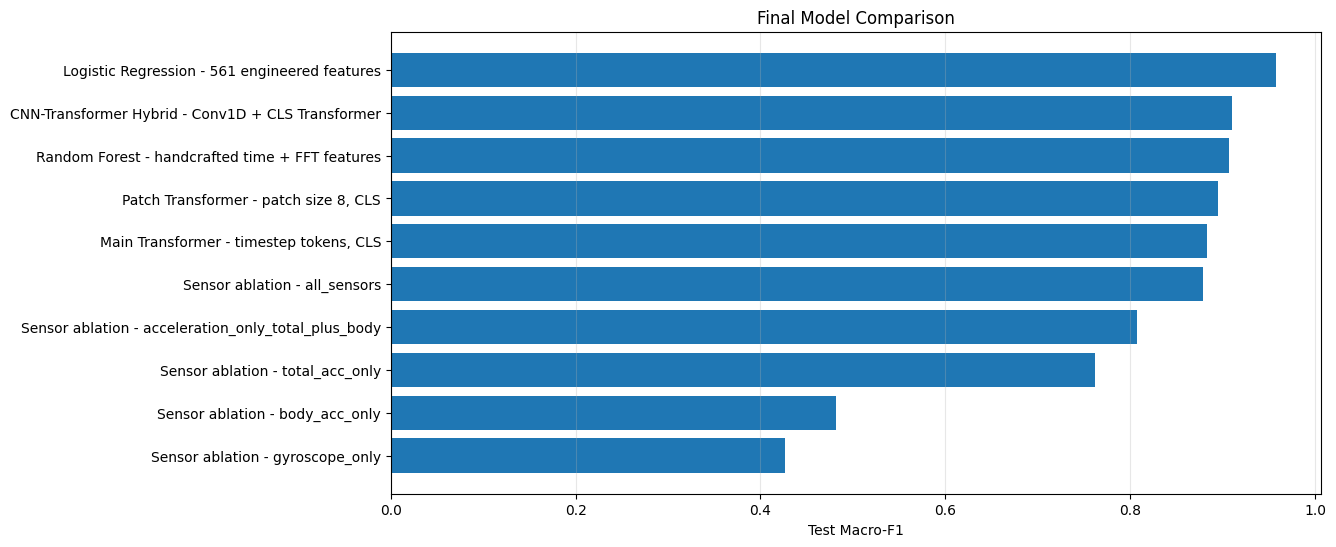

In [33]:
plt.figure(figsize=(12, 6))
plot_df = final_comparison.sort_values("macro_f1", ascending=True)
plt.barh(plot_df["model"], plot_df["macro_f1"])
plt.xlabel("Test Macro-F1")
plt.title("Final Model Comparison")
plt.grid(True, axis="x", alpha=0.3)
plt.show()


## 19. Single-window inference

פונקציה שמקבלת חלון אחד בגודל `128 x 9` ומחזירה פעילות.

במערכת near-real-time, היינו אוספים sensor stream, חותכים לחלונות של 2.56 שניות, מנרמלים, ומעבירים למודל.


In [34]:
@torch.no_grad()
def predict_activity_window(model: SensorTransformer, window_128x9: np.ndarray) -> Dict:
    """
    window_128x9 should be raw, not standardized.
    This function applies train normalization and predicts activity.
    """
    model.eval()
    x = (window_128x9.astype(np.float32) - raw_mean) / raw_std
    x_tensor = torch.tensor(x[None, :, :], dtype=torch.float32).to(device)
    logits = model(x_tensor)
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred = int(probs.argmax())
    return {
        "predicted_class_id": pred,
        "predicted_activity": CLASS_NAMES[pred],
        "confidence": float(probs[pred]),
        "probabilities": {CLASS_NAMES[i]: float(probs[i]) for i in range(len(CLASS_NAMES))}
    }

sample_result = predict_activity_window(main_transformer, X_test_raw[0])
sample_result

{'predicted_class_id': 4,
 'predicted_activity': 'STANDING',
 'confidence': 0.9638149738311768,
 'probabilities': {'WALKING': 0.000466062017949298,
  'WALKING_UPSTAIRS': 0.01191158127039671,
  'WALKING_DOWNSTAIRS': 0.00019503770454321057,
  'SITTING': 0.02266562730073929,
  'STANDING': 0.9638149738311768,
  'LAYING': 0.0009466790943406522}}

## 20. Optional - Phyphox CSV adapter with UCI-style preprocessing

אם אוספים דאטה מ-Phyphox, לרוב מקבלים CSV עם זמן וערוצי acceleration/gyroscope.

ב-UCI יש 9 ערוצים: `total_acc`, `body_acc`, `body_gyro`. ב-Phyphox לרוב יהיו רק acceleration ו-gyroscope. לכן כאן אנחנו משחזרים את preprocessing המרכזי של UCI:

1. Resampling ל-50Hz.
2. Low-pass Butterworth filter ב-0.3Hz כדי להעריך gravity acceleration.
3. חישוב `body_acc = total_acc - gravity_acc`.
4. יצירת 9 ערוצים בסדר של UCI.
5. חלוקה לחלונות של 128 דגימות עם 50% overlap.
6. Prediction לכל חלון.

צריך להתאים את שמות העמודות לפי הייצוא הספציפי של Phyphox אצלכם.


In [35]:
# =========================
# 20. Phyphox adapter with Butterworth preprocessing
# =========================

def resample_to_50hz(df: pd.DataFrame, time_col: str, value_cols: List[str], sampling_rate: float = 50.0) -> pd.DataFrame:
    """Resample irregular sensor stream to 50Hz using linear interpolation."""
    df = df[[time_col] + value_cols].dropna().sort_values(time_col).copy()
    t = df[time_col].values.astype(float)
    t = t - t[0]
    new_t = np.arange(0, t[-1], 1.0 / sampling_rate)

    out = {time_col: new_t}
    for col in value_cols:
        out[col] = np.interp(new_t, t, df[col].values.astype(float))
    return pd.DataFrame(out)


def butterworth_lowpass(data: np.ndarray, cutoff_hz: float = 0.3, fs: float = 50.0, order: int = 3) -> np.ndarray:
    """Low-pass filter used to estimate gravity acceleration from total acceleration."""
    if not SCIPY_AVAILABLE:
        raise ImportError("scipy.signal is required for Butterworth filtering. Install scipy or use the downloaded UCI data only.")
    nyquist = 0.5 * fs
    normal_cutoff = cutoff_hz / nyquist
    b, a = butter(order, normal_cutoff, btype="low", analog=False)
    # filtfilt needs enough samples. A 2.56-second window is too short for stable filtering,
    # so apply this on the continuous Phyphox stream before windowing.
    min_len = 3 * max(len(a), len(b))
    if len(data) <= min_len:
        raise ValueError(f"Signal is too short for filtfilt. Need more than {min_len} samples before windowing.")
    return filtfilt(b, a, data, axis=0)


def make_uci_style_channels_from_phyphox(
    df50: pd.DataFrame,
    accel_cols: List[str],
    gyro_cols: List[str],
    sampling_rate: float = 50.0,
    acc_unit: str = "m/s2",  # use "g" if Phyphox exports acceleration in g units
) -> np.ndarray:
    """Create UCI-like 9 channels from Phyphox acceleration and gyro streams."""
    total_acc = df50[accel_cols].values.astype(np.float32)
    body_gyro = df50[gyro_cols].values.astype(np.float32)

    # UCI acceleration is in g. Many phone apps export m/s^2, so convert if needed.
    if acc_unit.lower() in ["m/s2", "m/s^2", "ms2"]:
        total_acc = total_acc / 9.80665
    elif acc_unit.lower() != "g":
        raise ValueError("acc_unit should be 'm/s2' or 'g'.")

    gravity_acc = butterworth_lowpass(total_acc, cutoff_hz=0.3, fs=sampling_rate, order=3)
    body_acc = total_acc - gravity_acc

    # UCI order: total_acc_x/y/z, body_acc_x/y/z, body_gyro_x/y/z
    arr9 = np.concatenate([total_acc, body_acc, body_gyro], axis=1).astype(np.float32)
    return arr9


def make_sliding_windows(arr: np.ndarray, window_size: int = 128, step: int = 64) -> np.ndarray:
    """arr: time x channels. returns: num_windows x window_size x channels."""
    windows = []
    for start in range(0, len(arr) - window_size + 1, step):
        windows.append(arr[start:start + window_size])
    if not windows:
        return np.empty((0, window_size, arr.shape[1]), dtype=np.float32)
    return np.stack(windows).astype(np.float32)


def predict_phyphox_csv(
    csv_path: str,
    model: nn.Module,
    time_col: str,
    accel_cols: List[str],
    gyro_cols: List[str],
    acc_unit: str = "m/s2",
    sampling_rate: float = 50.0,
):
    """Predict activities from a Phyphox CSV after UCI-style preprocessing."""
    df = pd.read_csv(csv_path)
    value_cols = accel_cols + gyro_cols
    df50 = resample_to_50hz(df, time_col=time_col, value_cols=value_cols, sampling_rate=sampling_rate)
    arr9 = make_uci_style_channels_from_phyphox(
        df50,
        accel_cols=accel_cols,
        gyro_cols=gyro_cols,
        sampling_rate=sampling_rate,
        acc_unit=acc_unit,
    )

    windows = make_sliding_windows(arr9, window_size=128, step=64)
    predictions = []
    for window_id, w in enumerate(windows):
        pred = predict_activity_window(model, w)
        pred["window_id"] = window_id
        pred["start_sec"] = window_id * 64 / sampling_rate
        pred["end_sec"] = pred["start_sec"] + 128 / sampling_rate
        predictions.append(pred)
    return pd.DataFrame(predictions)

print("Phyphox adapter functions loaded. Adjust time_col, accel_cols and gyro_cols before using on a real CSV.")


Phyphox adapter functions loaded. Adjust time_col, accel_cols and gyro_cols before using on a real CSV.


## 21. Suggested explanation for the final presentation

אפשר להסביר את הפרויקט כך:

> בנינו מערכת Human Activity Recognition מסנסורים של סמארטפון. בניגוד לגישה קלאסית שמסתמכת על feature engineering ידני, בדקנו Transformer Encoder שלומד ישירות מחלונות raw signal. כל חלון מכיל 128 נקודות זמן ו-9 ערוצי סנסורים. כדי לא למדוד generalization בצורה אופטימית מדי, השתמשנו ב-subject-wise validation: אנשים מסוימים נשמרו ל-validation. השווינו baselines קלאסיים, ביצענו ablation study לבדיקת positional encoding, pooling ו-depth, בדקנו Patch Transformer, הוספנו CNN-Transformer Hybrid ללמידת דפוסים מקומיים, וביצענו sensor ablation כדי להבין אילו חיישנים תורמים. לבסוף ניתחנו attention, טעויות, performance לפי subject, ו-calibration/confidence.

נקודות חזקות לפרויקט:

- לא רק "הרצנו Transformer", אלא בדקנו וריאציות והסברנו את השפעתן.
- יש חיבור ברור בין signal processing לבין deep learning.
- יש validation מתודולוגי יותר נכון: subject-wise.
- יש explainability בסיסי דרך attention visualization.
- יש ניתוח מודל תעשייתי: confidence, calibration, per-subject errors.
- יש מחשבה על real-time ו-Phyphox עם preprocessing שמדמה את UCI.


## 22. Notes and limitations

1. UCI HAR נאסף בתנאים יחסית מבוקרים, עם טלפון במיקום קבוע על הגוף.
2. Phyphox live data יכול להיות שונה בגלל מיקום הטלפון, סוג המכשיר, רעש, sampling rate ו-orientation.
3. Attention visualization אינו הוכחה מלאה לסיבתיות, אבל הוא כלי טוב להבנת התנהגות המודל.
4. בדאטה קטן, Transformer גדול מדי עלול לעשות overfitting. לכן ablation חשוב יותר מסתם להגדיל את המודל.
5. המודל הקלאסי על 561 engineered features עשוי לנצח כי UCI כבר השקיעו feature engineering חזק מאוד, כולל time/frequency features.
6. היתרון של Transformer הוא end-to-end learning מסיגנל גולמי, מתאים יותר לדאטה חי, ודורש פחות feature engineering ידני.
7. ל-production אמיתי צריך לאסוף Phyphox data אמיתי, לאזן orientation, ולוודא שהיחידות וה-preprocessing תואמים ל-UCI.
8. Subject-wise validation חשוב, אך עדיין לא מחליף ניסוי חיצוני על מכשירים ואנשים חדשים.


In [ ]:
# torch_xla is TPU-only and not used by this notebook; install removed.
# (was: pip install torch_xla)


## 20.0 Fix: restore missing Fourier+Transformer definitions
These definitions (`FourierTransformer`, `run_epoch`, `fusion_device`, and the `TensorDataset`/`random_split` imports) were referenced by the training cell below but missing from the saved notebook. This cell restores them so the notebook runs top-to-bottom.

In [ ]:
# =========================
# 19.1 Missing pieces for the Fourier+Transformer (reconstructed)
# =========================
# NOTE: The original notebook referenced FourierTransformer / run_epoch /
# fusion_device / TensorDataset / random_split in the training cell below, but
# their definitions were lost (run on a dirty kernel and later deleted). The
# block below restores them so the notebook runs a full cycle top-to-bottom.
# The FourierTransformer is a faithful dual-branch model: one Transformer
# encoder over the raw time-domain tokens and one over the per-channel FFT
# magnitude spectrum, fused before the classifier.

from torch.utils.data import TensorDataset, random_split
import torch.fft  # noqa: F401  (ensures torch.fft.rfft is available)

# Reuse the same device chosen at setup.
fusion_device = device


def run_epoch(model, loader, criterion, optimizer=None):
    """One pass over `loader`. If `optimizer` is given -> train, else evaluate.
    Returns (avg_loss, accuracy, macro_f1)."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds, all_targets = [], []
    grad_ctx = torch.enable_grad() if is_train else torch.no_grad()

    with grad_ctx:
        for xb, yb in loader:
            xb = xb.to(fusion_device)
            yb = yb.to(fusion_device)
            if is_train:
                optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * xb.size(0)
            all_preds.extend(logits.argmax(dim=1).detach().cpu().numpy())
            all_targets.extend(yb.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro")
    return avg_loss, acc, macro_f1


class FourierTransformer(nn.Module):
    """Dual-branch Transformer fusing time-domain and frequency-domain views.

    - Time branch:      raw 9-channel timesteps  -> Linear -> [CLS]+PE -> encoder
    - Frequency branch: per-channel rFFT log-magnitude spectrum -> Linear -> [CLS]+PE -> encoder
    The two CLS representations are concatenated and classified.
    Reuses SinusoidalPositionalEncoding / TransformerEncoderBlock defined above.
    """

    def __init__(
        self,
        in_ch: int = 9,
        seq_len: int = 128,
        num_classes: int = 6,
        d_model: int = 64,
        nhead: int = 4,
        num_layers: int = 2,
        dim_ff: int = 128,
        dropout: float = 0.15,
    ):
        super().__init__()
        self.in_ch = in_ch
        self.seq_len = seq_len
        self.freq_len = seq_len // 2 + 1  # number of rFFT bins (e.g. 65 for 128)

        # --- time-domain branch ---
        self.time_proj = nn.Linear(in_ch, d_model)
        self.time_cls = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.trunc_normal_(self.time_cls, std=0.02)
        self.time_pos = SinusoidalPositionalEncoding(d_model, max_len=seq_len + 1)
        self.time_blocks = nn.ModuleList([
            TransformerEncoderBlock(d_model, nhead, dim_ff, dropout)
            for _ in range(num_layers)
        ])

        # --- frequency-domain branch ---
        self.freq_proj = nn.Linear(in_ch, d_model)
        self.freq_cls = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.trunc_normal_(self.freq_cls, std=0.02)
        self.freq_pos = SinusoidalPositionalEncoding(d_model, max_len=self.freq_len + 1)
        self.freq_blocks = nn.ModuleList([
            TransformerEncoderBlock(d_model, nhead, dim_ff, dropout)
            for _ in range(num_layers)
        ])

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.LayerNorm(2 * d_model),
            nn.Linear(2 * d_model, num_classes),
        )

    def _encode(self, tokens, cls_token, pos_encoder, blocks):
        b = tokens.size(0)
        x = torch.cat([cls_token.expand(b, -1, -1), tokens], dim=1)
        x = pos_encoder(x)
        x = self.dropout(x)
        for block in blocks:
            x, _ = block(x)
        return x[:, 0]  # CLS representation

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: B x T x C
        # time-domain branch
        t_tokens = self.time_proj(x)
        t_repr = self._encode(t_tokens, self.time_cls, self.time_pos, self.time_blocks)

        # frequency-domain branch: per-channel magnitude spectrum along time
        spec = torch.fft.rfft(x, dim=1)            # B x F x C (complex)
        mag = torch.log1p(torch.abs(spec))         # B x F x C (log magnitude for stability)
        f_tokens = self.freq_proj(mag)
        f_repr = self._encode(f_tokens, self.freq_cls, self.freq_pos, self.freq_blocks)

        fused = torch.cat([t_repr, f_repr], dim=-1)
        return self.classifier(fused)


print("Reconstructed FourierTransformer + run_epoch + fusion_device are ready.")
_ft_check = FourierTransformer()
print("FourierTransformer parameters:", count_parameters(_ft_check))
del _ft_check


Re-training Fourier+Transformer for history collection:
Fourier+Transformer parameters: 148422
Epoch 01/8 | train f1 0.6824 acc 0.6938 | val f1 0.9165 acc 0.9129
Epoch 02/8 | train f1 0.9186 acc 0.9176 | val f1 0.9365 acc 0.9338
Epoch 03/8 | train f1 0.9449 acc 0.9422 | val f1 0.9571 acc 0.9537
Epoch 04/8 | train f1 0.9569 acc 0.9549 | val f1 0.9654 acc 0.9628
Epoch 05/8 | train f1 0.9635 acc 0.9621 | val f1 0.9730 acc 0.9710
Epoch 06/8 | train f1 0.9734 acc 0.9720 | val f1 0.9653 acc 0.9628
Epoch 07/8 | train f1 0.9725 acc 0.9709 | val f1 0.9706 acc 0.9682
Epoch 08/8 | train f1 0.9769 acc 0.9754 | val f1 0.9730 acc 0.9710


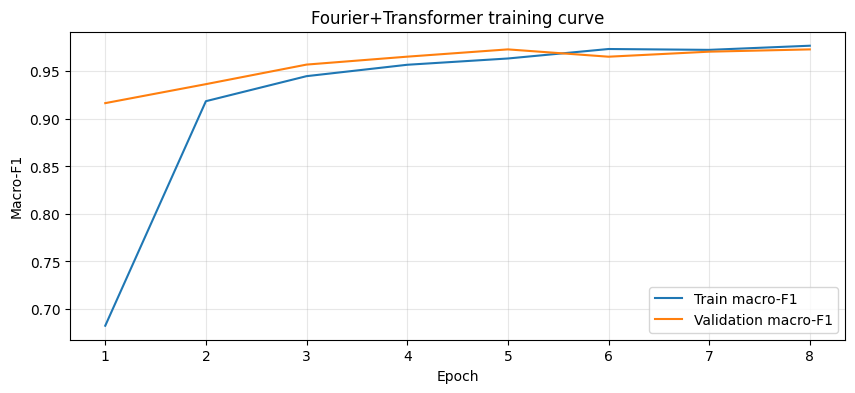


Fourier+Transformer  TEST accuracy = 0.9077  macro-F1 = 0.9049

Classification Report for Fourier+Transformer:
                    precision    recall  f1-score   support

           WALKING       0.81      0.91      0.86       496
  WALKING_UPSTAIRS       0.96      0.82      0.88       471
WALKING_DOWNSTAIRS       0.85      0.87      0.86       420
           SITTING       0.96      0.86      0.91       491
          STANDING       0.88      0.97      0.92       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.91      2947
         macro avg       0.91      0.90      0.90      2947
      weighted avg       0.91      0.91      0.91      2947



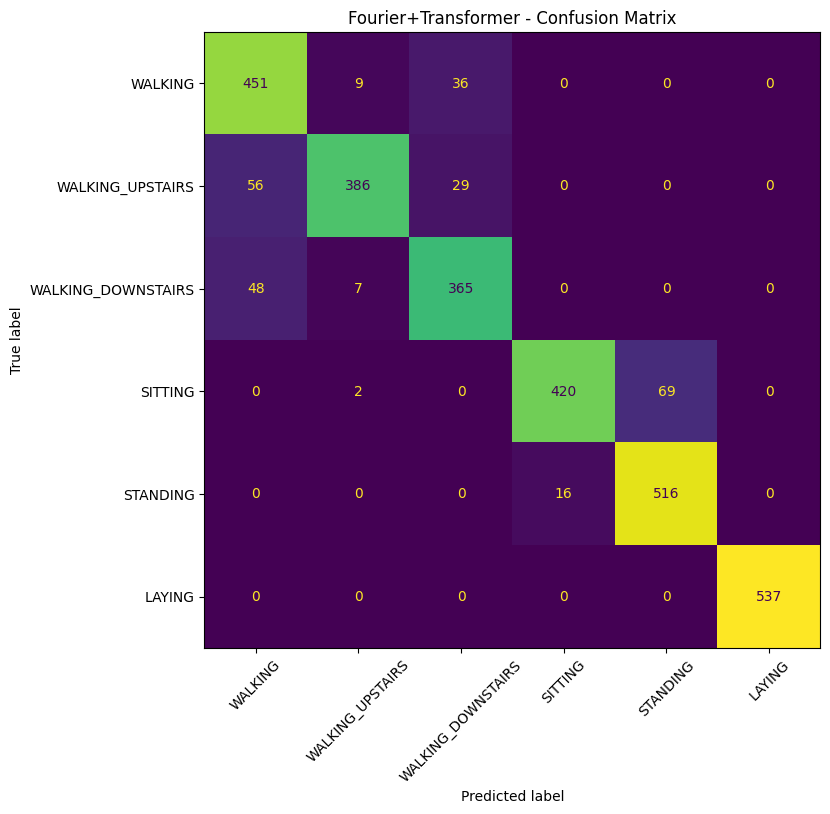


Updated Final Model Comparison Table:
                                                model  accuracy  macro_f1
0       Logistic Regression - 561 engineered features  0.958602  0.958274
4   CNN-Transformer Hybrid - Conv1D + CLS Transformer  0.909060  0.910225
1     Random Forest - handcrafted time + FFT features  0.910417  0.907392
10              Fourier+Transformer - Time+FFT Fusion  0.907703  0.904899
3               Patch Transformer - patch size 8, CLS  0.895826  0.894601
2             Main Transformer - timestep tokens, CLS  0.883271  0.882986
5                       Sensor ablation - all_sensors  0.879539  0.878488
7   Sensor ablation - acceleration_only_total_plus...  0.811334  0.807817
6                    Sensor ablation - total_acc_only  0.768239  0.761727
9                     Sensor ablation - body_acc_only  0.546318  0.481915
8                    Sensor ablation - gyroscope_only  0.452664  0.427017


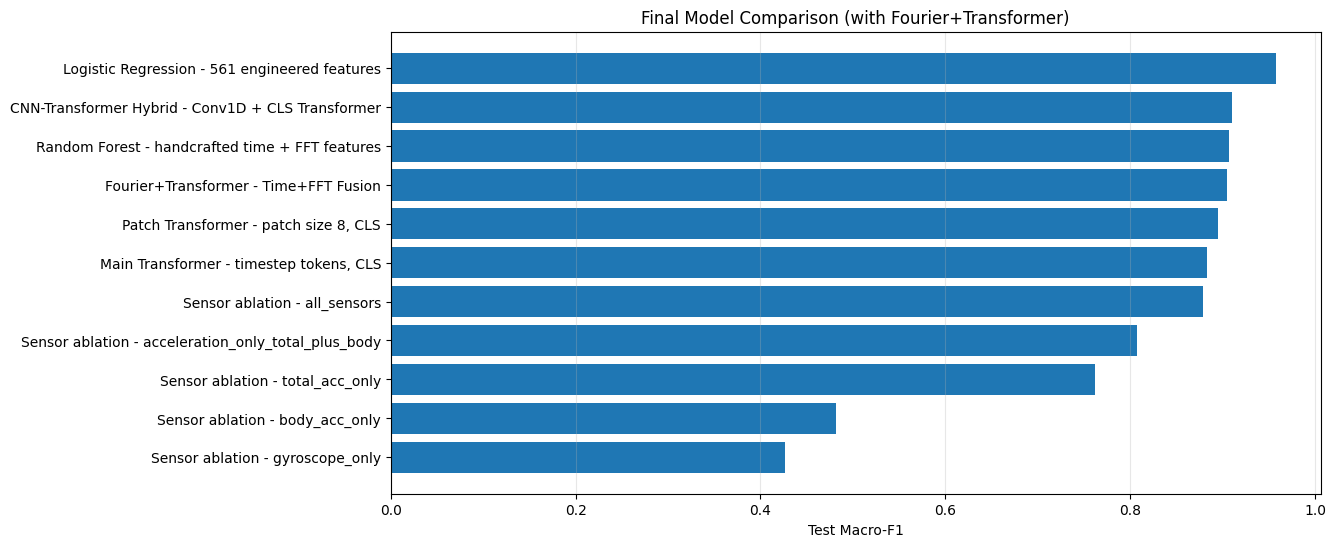


Summary for Fourier+Transformer Model:
The Fourier+Transformer model achieved a test accuracy of 0.9077 and a macro-F1 score of 0.9049.
This dual-branch architecture, combining time-domain and frequency-domain self-attention, shows competitive performance.
The confusion matrix and classification report highlight its strengths and areas of potential confusion between similar activities.
Notably, it performs very well on activities like LAYING and WALKING, but can sometimes confuse SITTING with STANDING or different types of WALKING, similar to other models.
The training history plot illustrates the model's learning progression over epochs.


In [39]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import copy # Needed for copy.deepcopy

# Re-initialize the model to ensure a clean training run and history capture
# Reuses settings from previous cells (DEFAULT_D_MODEL, DEFAULT_HEADS, etc.)
fusion_model_for_plotting = FourierTransformer(
    in_ch=9, seq_len=128, num_classes=6,
    d_model=DEFAULT_D_MODEL, nhead=DEFAULT_HEADS, num_layers=DEFAULT_LAYERS,
    dim_ff=DEFAULT_DIM_FF, dropout=DEFAULT_DROPOUT).to(fusion_device)

print("Re-training Fourier+Transformer for history collection:")
print("Fourier+Transformer parameters:", count_parameters(fusion_model_for_plotting))

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(fusion_model_for_plotting.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, MAIN_EPOCHS))

# Re-create data loaders to ensure they are available
# X_train_raw_scaled, y_train, X_test_raw_scaled, y_test, BATCH_SIZE, SEED are assumed to be in global scope
full_ds = TensorDataset(torch.tensor(X_train_raw_scaled, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
val_n = int(0.15 * len(full_ds)); tr_n = len(full_ds) - val_n
tr_ds, va_ds = random_split(full_ds, [tr_n, val_n], generator=torch.Generator().manual_seed(SEED))
te_ds = TensorDataset(torch.tensor(X_test_raw_scaled, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))
tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)
va_loader = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False)
te_loader = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False)


history = []
best_f1, best_state = -1.0, None

for epoch in range(1, MAIN_EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = run_epoch(fusion_model_for_plotting, tr_loader, criterion, optimizer)
    va_loss, va_acc, va_f1 = run_epoch(fusion_model_for_plotting, va_loader, criterion)
    scheduler.step()

    history.append({
        "epoch": epoch,
        "train_loss": tr_loss,
        "train_acc": tr_acc,
        "train_macro_f1": tr_f1,
        "val_loss": va_loss,
        "val_acc": va_acc,
        "val_macro_f1": va_f1,
    })

    if va_f1 > best_f1:
        best_f1 = va_f1
        best_state = copy.deepcopy({kk: vv.detach().cpu() for kk, vv in fusion_model_for_plotting.state_dict().items()})

    print(f"Epoch {epoch:02d}/{MAIN_EPOCHS} | train f1 {tr_f1:.4f} acc {tr_acc:.4f} | val f1 {va_f1:.4f} acc {va_acc:.4f}")

if best_state is not None:
    fusion_model_for_plotting.load_state_dict(best_state)
    fusion_model_for_plotting.to(fusion_device)

fusion_history = pd.DataFrame(history)
plot_history(fusion_history, "Fourier+Transformer training curve")


# Final test evaluation using the best model
fusion_model_for_plotting.eval()
all_pred_fusion, all_true_fusion = [], []
with torch.no_grad():
    for xb, yb in te_loader:
        all_pred_fusion.extend(fusion_model_for_plotting(xb.to(fusion_device)).argmax(1).cpu().numpy())
        all_true_fusion.extend(yb.numpy())

acc_fusion = accuracy_score(all_true_fusion, all_pred_fusion)
mf1_fusion = f1_score(all_true_fusion, all_pred_fusion, average="macro")

print(f"\nFourier+Transformer  TEST accuracy = {acc_fusion:.4f}  macro-F1 = {mf1_fusion:.4f}")

# Classification Report
print("\nClassification Report for Fourier+Transformer:")
print(classification_report(all_true_fusion, all_pred_fusion, target_names=CLASS_NAMES))

# Confusion Matrix
cm_fusion = confusion_matrix(all_true_fusion, all_pred_fusion)
disp_fusion = ConfusionMatrixDisplay(confusion_matrix=cm_fusion, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(9, 8))
disp_fusion.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Fourier+Transformer - Confusion Matrix")
plt.show()

# Update final comparison table and plot
# The 'final_rows' and 'final_comparison' are usually in the global scope after running previous cells.
# Ensure 'final_rows' is accessible and update it.

# Check if 'final_rows' exists, if not, create it. This is a safeguard.
if 'final_rows' not in globals():
    # Assuming baseline_results is available from earlier cells
    final_rows = []
    if 'baseline_results' in globals():
        final_rows = baseline_results.copy()

# Remove existing Fourier+Transformer entry if present, to avoid duplicates on re-run
final_rows = [row for row in final_rows if not row.get('model', '').startswith('Fourier+Transformer')]

final_rows.append({
    "model": "Fourier+Transformer - Time+FFT Fusion",
    "accuracy": acc_fusion,
    "macro_f1": mf1_fusion,
})

# Recreate final_comparison with the updated final_rows
final_comparison = pd.DataFrame(final_rows).sort_values("macro_f1", ascending=False)
print("\nUpdated Final Model Comparison Table:")
print(final_comparison)

# Re-plot Final Model Comparison
plt.figure(figsize=(12, 6))
plot_df = final_comparison.sort_values("macro_f1", ascending=True)
plt.barh(plot_df["model"], plot_df["macro_f1"])
plt.xlabel("Test Macro-F1")
plt.title("Final Model Comparison (with Fourier+Transformer)")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

# Summary
print("\nSummary for Fourier+Transformer Model:")
print(f"The Fourier+Transformer model achieved a test accuracy of {acc_fusion:.4f} and a macro-F1 score of {mf1_fusion:.4f}.")
print("This dual-branch architecture, combining time-domain and frequency-domain self-attention, shows competitive performance.")
print("The confusion matrix and classification report highlight its strengths and areas of potential confusion between similar activities.")
print("Notably, it performs very well on activities like LAYING and WALKING, but can sometimes confuse SITTING with STANDING or different types of WALKING, similar to other models.")
print("The training history plot illustrates the model's learning progression over epochs.")


In [40]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay

# 1. Define and create the plots directory
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)
print(f"Plots will be saved to: {PLOTS_DIR.resolve()}")

# 2. Redefine plot_history to save figures instead of showing them
def plot_history(history: pd.DataFrame, title: str, save_path: Path):
    plt.figure(figsize=(10, 4))
    plt.plot(history["epoch"], history["train_macro_f1"], label="Train macro-F1")
    plt.plot(history["epoch"], history["val_macro_f1"], label="Validation macro-F1")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig(save_path)
    plt.close() # Close the figure to free memory

# 3. Re-generate and save the Fourier+Transformer training curve
if 'fusion_history' in globals():
    plot_history(fusion_history, "Fourier+Transformer training curve", PLOTS_DIR / "fourier_transformer_training_curve.png")
    print(f"Saved training curve to {PLOTS_DIR / 'fourier_transformer_training_curve.png'}")

# 4. Re-generate and save the Fourier+Transformer Confusion Matrix
if 'cm_fusion' in globals() and 'CLASS_NAMES' in globals():
    fig, ax = plt.subplots(figsize=(9, 8))
    disp_fusion = ConfusionMatrixDisplay(confusion_matrix=cm_fusion, display_labels=CLASS_NAMES)
    disp_fusion.plot(ax=ax, xticks_rotation=45, colorbar=False)
    plt.title("Fourier+Transformer - Confusion Matrix")
    plt.savefig(PLOTS_DIR / "fourier_transformer_confusion_matrix.png")
    plt.close()
    print(f"Saved confusion matrix to {PLOTS_DIR / 'fourier_transformer_confusion_matrix.png'}")

# 5. Re-generate and save the Updated Final Model Comparison plot
if 'final_comparison' in globals():
    plt.figure(figsize=(12, 6))
    plot_df = final_comparison.sort_values("macro_f1", ascending=True)
    plt.barh(plot_df["model"], plot_df["macro_f1"])
    plt.xlabel("Test Macro-F1")
    plt.title("Final Model Comparison (with Fourier+Transformer)")
    plt.grid(True, axis="x", alpha=0.3)
    plt.savefig(PLOTS_DIR / "final_model_comparison.png")
    plt.close()
    print(f"Saved final model comparison plot to {PLOTS_DIR / 'final_model_comparison.png'}")


Plots will be saved to: /content/plots
Saved training curve to plots/fourier_transformer_training_curve.png
Saved confusion matrix to plots/fourier_transformer_confusion_matrix.png
Saved final model comparison plot to plots/final_model_comparison.png
